In [ ]:
pip install genieclust

In [ ]:
pip install pyclustering

In [ ]:
pip install openml

In [ ]:
pip install optuna

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
rng = np.random.default_rng()
from scipy.cluster import  hierarchy
from scipy.cluster.hierarchy import fcluster
import genieclust
from pyclustering.cluster.kmedoids import kmedoids
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_samples
import openml
from sklearn.model_selection import train_test_split
import time
from sklearn.datasets import make_blobs, make_circles, make_moons, make_regression
from matplotlib.colors import ListedColormap
import cluster_master

Pytania i wnioski wstępne

*   NCA: uwaga na liczności grup, w szczególności gdy korzystamy z dbscan, outliery to oddzielna klasa
*   master_cluster.py - potencjalnie wstawienie modyfikacji niektorych metryk zrobionych w tym pliku, zamiast modeli wstawiamy `labels`.
*   kmedoids z pyclustering byc moze bardziej reczne wykonywania, niz mialoby to miejsce w przypadku tego z sklearn-extra, ale dziala
*   Zbior bramkarze, te zbiory dotycza sezonu 2022/2023 oraz są zebrane tylko z lig krajowych
*   Genieclust algorytmy klasteryzacji - w zasadzie bardziej reczna klasteryzacja hierarchiczna


Cel



*   Porównanie algorytmów grupowania danych dla różnych problemów.
*   Sprawdzenie algorytmów pod kątem wrażliwości na skalowanie danych.
*   Jak ocenić jakość klasteryzacji?
*   Zastosowania wyników analizy skupień w eksploracji danych.



### Znaleziska
https://github.com/gagolews/clustering-data-v1/tree/master/wut




### Analiza skupień

Takie podejście charakteryzuje się głównie poszukiwaniem głównych wzorców i struktury w danych bazując jedynie na zmiennych objaśniających. Jego celem jest podział zbioru danych na $k$ rozłącznych grup (skupień) tak, aby obserwacje wewnątrz były między sobą możliwie jak najbardziej podobne.

### Dane symulowane

In [ ]:
# https://scikit-learn.org/stable/auto_examples/linear_model/plot_logistic_multinomial.html

In [ ]:
centers = [[-5, 0], [0, 1.5], [5, -1]]
X1, y1 = make_blobs(n_samples=1_000, centers=centers, random_state=40)
transformation = [[0.4, 0.2], [-0.4, 1.2]]
X1 = np.dot(X1, transformation)

plt.scatter(X1[:, 0], X1[:, 1], c=y1,alpha=0.5)
plt.show()

In [ ]:
X2, y2 = make_moons(n_samples=500, noise=0.1, random_state=13)
plt.scatter(X2[:,0], X2[:,1],c=y2,alpha=0.5)
plt.show()

In [ ]:
X3, y3 = make_circles(n_samples = 500,factor=0.5, noise=0.07, random_state=13 )
sauron = ListedColormap([ "orange","black"])
plt.scatter(X3[:,0], X3[:,1],c=y3,cmap=sauron,alpha=0.5)
plt.show()

In [ ]:
X4 = pd.read_csv('labirynth.data.gz',compression = 'gzip',header=None,sep=r"\s+")
y4 = pd.read_csv('labirynth.labels0.gz',compression = 'gzip',header=None)
X4 =X4.to_numpy()
y4 = np.asarray(y4).ravel()
plt.scatter(X4[:,0], X4[:,1],c=y4,alpha=0.5)
plt.show()

In [ ]:
X5 = pd.read_csv('stripes.data.gz',compression = 'gzip',header=None,sep=r"\s+")
y5 = pd.read_csv('stripes.labels0.gz',compression = 'gzip',header=None)
X5 =X5.to_numpy()
y5 = np.asarray(y5).ravel()
plt.scatter(X5[:,0], X5[:,1],c=y5,alpha=0.5)
plt.show()

In [ ]:
X6 = pd.read_csv('mk3.data.gz',compression = 'gzip',header=None,sep=r"\s+")
y6 = pd.read_csv('mk3.labels0.gz',compression = 'gzip',header=None)
X6 =X6.to_numpy()
y6 = np.asarray(y6).ravel()
fig = plt.figure(figsize=(6,8))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(X6[:,0], X6[:,1], X6[:,2], c=y6)
plt.show()

In [ ]:
X7 = pd.read_csv('mk4.data.gz',compression = 'gzip',header=None,sep=r"\s+")
y7 = pd.read_csv('mk4.labels0.gz',compression = 'gzip',header=None)
X7 =X7.to_numpy()
y7 = np.asarray(y7).ravel()
fig = plt.figure(figsize=(6,8))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(X7[:,0], X7[:,1], X7[:,2], c=y7)
plt.show()

In [ ]:
X8 = pd.read_csv('windows.data.gz',compression = 'gzip',header=None,sep=r"\s+")
y8 = pd.read_csv('windows.labels0.gz',compression = 'gzip',header=None)
X8 =X8.to_numpy()
y8 = np.asarray(y8).ravel()
plt.scatter(X8[:,0], X8[:,1],c=y8,alpha=0.5)
plt.show()

In [ ]:
X_regression, y_regression= make_regression(n_samples = 400, n_features=6,n_informative=3, noise=2, random_state=13 )
idx = np.random.permutation(len(X_regression))

x1 = X_regression[idx[:100]]
x2 = X_regression[idx[100:200]]
x3 = X_regression[idx[200:300]]
x4 = X_regression[idx[300:]]


x3[:, :3] *= 0.5
x3[:, 3:] *= 2
x3 += np.array([-5, 7, 4, 0, 0, 0])

x2[:, :3] *= 2
x2[:, 3:] *= 0.5
x2 += np.array([7, 13, -2, 0, 0, 0])

x4[:, :3] *= 0.75
x4[:, 3:] *= 0.75
x4 += np.array([-3, -7, -9, 0, 0, 0])


X9 = np.vstack([x1, x2, x3, x4])

y9 = np.array([0]*100 + [1]*100 + [2]*100+[3]*100)

In [ ]:
plt.scatter(X9[:, 0], X9[:, 1], c=y9,alpha=0.5)
plt.show()

In [ ]:
X10 = pd.read_csv('hepta.data.gz',compression = 'gzip',header=None,sep=r"\s+")
y10 = pd.read_csv('hepta.labels0.gz',compression = 'gzip',header=None)
X10 =X10.to_numpy()
y10 = np.asarray(y10).ravel()
fig = plt.figure(figsize=(6,8))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(X10[:,0], X10[:,1], X10[:,2], c=y10)
plt.show()

In [ ]:
X11= pd.read_csv('olympic.data.gz',compression = 'gzip',header=None,sep=r"\s+")
y11 = pd.read_csv('olympic.labels0.gz',compression = 'gzip',header=None)
X11=X11.to_numpy()
y11 = np.asarray(y11).ravel()
olympics = ListedColormap(['blue','black','red','yellow','green'])
plt.scatter(X11[:,0], X11[:,1],c=y11,cmap=olympics,alpha=0.5)
plt.show()

### Algorytm k-średnich

Takie rozwiązanie będzie oparte o minimalizację sumy kwadratów odległości między obserwacjami, a środkami ich grup (centroidami). Można to formalnie zapisać jako problem minimalizacji:

$$SSE = \sum_{i=1}^{k} \sum_{x\in C_i} ||x-\mu_i||^2,$$

gdzie $k$ oznacza liczba skupień, $C_i$ zbiór punktów należących do $i$-tego skupienia dla $i=1,\ldots,k$ oraz $\mu_i$ to średnia arytmetyczna punktów w skupieniu $C_i$ (centroid).




Można zauważyć, że dla pewnej stałej $\sigma>0$ zachodzi:
$$-\sum_{i=1}^{k} \sum_{x\in C_i}\frac{ ||x-\mu_i||^2}{2\sigma^2}=\log \prod_{i=1}^{k}\prod _{x\in C_i} \exp\{-\frac{ (x-\mu_i)'(x-\mu_i)}{2\sigma^2}\}.$$

Stąd wcześniej rozważane zadanie minimalizacji SSE jest równoważne maksymalizacji funkcji wiarogodności przy założeniach:

1.   Każda obserwacja $x\in C_i$, gdzie $C_i$ jest najbliższym skupieniem (w sensie odległości euklidesowej).
2.   Każde skupienie $C_i$ ma rozkład wielowymiarowy normalny postaci $N(\mu_i,\sigma^2 I)$ dla $i=1,\ldots,k$ oraz $\sigma>0$.
3.   Dla każdej grupy $C_i$ rozkłady mają tę samą macierz kowariancji.



In [ ]:
kmeans1 = KMeans(n_clusters=3, random_state= 3, n_init=1)
kmeans1.fit(X1)
plt.scatter(X1[:,0],X1[:,1],c=kmeans1.labels_,alpha=0.4)
plt.scatter(kmeans1.cluster_centers_[:,0], kmeans1.cluster_centers_[:,1], c = np.unique(kmeans1.labels_),alpha=0.75,marker='o',edgecolors='black', s=100)
plt.show()

In [ ]:
kmeans2 = KMeans(n_clusters=2, random_state= 3, n_init=1)
kmeans2.fit(X2)
plt.scatter(X2[:,0],X2[:,1],c=kmeans2.labels_,alpha=0.4)
plt.scatter(kmeans2.cluster_centers_[:,0], kmeans2.cluster_centers_[:,1], c = np.unique(kmeans2.labels_),alpha=0.75,marker='o',edgecolors='black', s=100)
plt.show()

Jak widzimy ten algorytm w wielu sytuacjach nie będzie w stanie znaleźć prawdziwych skupień. Co więcej, aby wytrenować model musimy wpierw narzucić sobie pewną liczbę skupień, co w praktyce może być niemożliwe.

### Algorytm k-medoidów

To rozwiązanie będzie zbliżone do poprzedniego, przy czym środkami grup będą punkty należące do rozpatrywanego zbioru danych (tzw. medoidy). Główną zaletą tego podejścia będzie przede wszystkim interpretowalność. Środki grup istnieją w rozpatrywanym zbiorze danych.

In [ ]:
kmeds1= kmedoids(X1,initial_index_medoids=[0,1,2])
kmeds1.process()
clust = kmeds1.get_clusters()
meds = kmeds1.get_medoids()
for i, cluster in enumerate(clust):
    x1 = [X1[idx][0] for idx in cluster]
    x2 = [X1[idx][1] for idx in cluster]
    plt.scatter(x1, x2 ,alpha = 0.5)
m1 = [X1[idx][0] for idx in meds]
m2 = [X1[idx][1] for idx in meds]
plt.scatter(m1,m2,edgecolors='black',marker='o',s=100)

plt.show()

In [ ]:
kmeds2= kmedoids(X2, initial_index_medoids=[0,1])
kmeds2.process()
clust = kmeds2.get_clusters()
meds = kmeds2.get_medoids()
for i, cluster in enumerate(clust):
    x1 = [X2[idx][0] for idx in cluster]
    x2 = [X2[idx][1] for idx in cluster]
    plt.scatter(x1, x2 ,alpha = 0.5)
m1 = [X2[idx][0] for idx in meds]
m2 = [X2[idx][1] for idx in meds]
plt.scatter(m1,m2,edgecolors='black',marker='o',s=100)

plt.show()

Podobnie jak wcześniej, widzimy że ten algorytm w wielu sytuacjach nie będzie w stanie znaleźć prawdziwych skupień oraz aby wytrenować model musimy spodziewać się pewnej liczby skupień.  

### DBSCAN

Idea: Znajdywanie skupień patrząc na najbliższe otoczenia kolejnych punktów.

Ustalamy dwie liczby $\varepsilon >0$ oraz $n_0\in\mathbb{N}$. Każdy punkt $x$, który w kuli o środku w $x$ oraz promieniu $\varepsilon$ zawiera więcej niż $n_0$ punktów będziemy nazywać *rdzeniem*, będzie on należeć do pewnego skupienia. Jeśli jednak w punkcie $x$ nie będzie zachodzić ta własność to wówczas punkt ten będzie *punktem granicznym* skupienia lub *szumem*.

Główną trudnością podczas zastosowania tego algorytmu do danych będzie dobranie długości promienia $\epsilon$ oraz minimalnej liczby punktów w otoczeniu $n_0$, aby punkt był rdzeniem.

Spróbujmy bez skalowania danych.

In [ ]:
db= DBSCAN(eps=0.4,min_samples=10)
db.fit(X1)
plt.scatter(X1[:, 0], X1[:, 1], c = db.labels_,alpha=0.5)
plt.show()

In [ ]:
E = [0.001,0.01,0.1,0.4,1,3,5,10,20]
time_fit = []

for e in E:
  start = time.perf_counter()
  db = DBSCAN(eps=e,min_samples=10)
  db.fit(X1)
  end = time.perf_counter()
  time_fit.append(end-start)

plt.plot(E, time_fit, marker="o")
plt.xlabel('eps')
plt.ylabel('time')
plt.title("time vs eps")
plt.tight_layout()
plt.show()

In [ ]:
samples = [3,4,5,6,7,8,9,10,15,20]
time_fit = []

for s in samples:
  start = time.perf_counter()
  db = DBSCAN(eps=0.4,min_samples=s)
  db.fit(X1)
  end = time.perf_counter()
  time_fit.append(end-start)

plt.plot(samples, time_fit, marker="o")
plt.xlabel('min_samples')
plt.ylabel('time')
plt.title("time vs min_samples")
plt.tight_layout()
plt.show()

In [ ]:
db= DBSCAN(eps=0.2,min_samples=10)
db.fit(X2)
plt.scatter(X2[:, 0], X2[:, 1], c = db.labels_,alpha=0.5)
plt.show()

In [ ]:
db= DBSCAN(eps=17,min_samples=5)
db.fit(X4)
plt.scatter(X4[:, 0], X4[:, 1], c = db.labels_,alpha=0.5)
plt.show()

In [ ]:
db= DBSCAN(eps=1,min_samples=10)
db.fit(X5)
plt.scatter(X5[:, 0], X5[:, 1], c = db.labels_,alpha=0.5)

In [ ]:
db= DBSCAN(eps=0.5,min_samples=6)
db.fit(X6)
fig = plt.figure(figsize=(6,8))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(X6[:,0], X6[:,1], X6[:,2], c=db.labels_,alpha=0.5)
plt.show()


In [ ]:
db= DBSCAN(eps=3,min_samples=6)
db.fit(X7)
fig = plt.figure(figsize=(6,8))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(X7[:,0], X7[:,1], X7[:,2], c=db.labels_,alpha=0.5)
plt.show()

In [ ]:
db= DBSCAN(eps=50,min_samples=10)
db.fit(X8)
plt.scatter(X8[:, 0], X8[:, 1], c = db.labels_,alpha=0.5)

In [ ]:
db= DBSCAN(eps=1,min_samples=6)
db.fit(X10)
fig = plt.figure(figsize=(6,8))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(X10[:,0], X10[:,1], X10[:,2], c=db.labels_,alpha=0.5)
plt.show()

In [ ]:
db= DBSCAN(eps=0.1,min_samples=10)
db.fit(X11)
plt.scatter(X11[:, 0], X11[:, 1], c = db.labels_,alpha=0.5)

A teraz ze skalowaniem

In [ ]:
X1_new= StandardScaler().fit_transform(X1)
db= DBSCAN(eps=0.2,min_samples=10)
db.fit(X1_new)
plt.scatter(X1_new[:, 0], X1_new[:, 1], c = db.labels_,alpha=0.5)

In [ ]:
X3_new= StandardScaler().fit_transform(X3)
db= DBSCAN(eps=0.33,min_samples=10)
db.fit(X3_new)
plt.scatter(X3_new[:, 0], X3_new[:, 1], c = db.labels_,alpha=0.5)

In [ ]:
X4_new= StandardScaler().fit_transform(X4)
db= DBSCAN(eps=0.07,min_samples=5)
db.fit(X4_new)
plt.scatter(X4_new[:, 0], X4_new[:, 1], c = db.labels_,alpha=0.5)

### Metody klasteryzacji hierarchicznej


W poprzedniej części pojawił się problem jak dobrać liczbę skupień, szczególnie, gdy nie wiemy czego się spodziewać, lub gdy dane są w więcej niż dwóch wymiarach i ciężko zaobserwować zależności w danych.

Rozwiązaniem są medoty klasteryzacji hierarchicznej. Polegają na utworzeniu pewnej hierarchii podziałów zaczynając od skupień, gdzie każde składa się z jednej obserwacji aż do jednego skupienia posiadającego wszystkie obserwacje. Sposoby rozwiązania tego problemu będą się opierać na łączeniu w coraz to liczniejsze skupienia elementów do siebie najbardziej podobnych za pomocą pewnej *miary podobieństwa*.

Rozważane miary podobieństwa:



*   Single linkage
*   Complete linkage
*   Average linkage
*   Kryterium Ward'a



In [ ]:
Z = hierarchy.linkage(X1, 'complete')
plt.figure()
dn = hierarchy.dendrogram(Z)
plt.axhline(y=8,color='red',linestyle='--')
plt.show()

In [ ]:
clusters = fcluster(Z,8,criterion='distance')
cluster_master.normalized_clustering_accuracy(y1,clusters)

In [ ]:
g = genieclust.Genie(n_clusters = 3)
labels =g.fit_predict(X1)
cluster_master.normalized_clustering_accuracy(y1,labels)

In [ ]:
Z1 = hierarchy.linkage(X2, 'complete')
plt.figure()
dn = hierarchy.dendrogram(Z1)

In [ ]:
Z1 = hierarchy.linkage(X11, 'average')
plt.figure()
dn = hierarchy.dendrogram(Z1)

In [ ]:
clusters= fcluster(Z1,5,criterion='maxclust')
plt.scatter(X11[:, 0], X11[:, 1], c = clusters,alpha=0.5)

In [ ]:
hier = genieclust.Genie(n_clusters=5)
clusters = hier.fit_predict(X11)
plt.scatter(X11[:, 0], X11[:, 1], c = clusters,alpha=0.5)

### Problem danych nieprzeskalowanych oraz obserwacji odstających

In [ ]:
#znajduje nam epsilona dla dbscan, żeby nca działało
def find_eps(X, k_true, min_samples=10, eps_range=None):
    """
    Szukamy najlepszego eps, tak by liczba klastrów się zgadzała
    z liczbą k_true. Zwraca epsilona lub None
    """

    #k_true = len(np.unique(y))

    if eps_range is None:
        eps_range = np.arange(0.05, 10.0, 0.05)

    best_eps = None
    best_noise_ratio = 1.0 #chcemy, żeby jak njamniej było obserwacji klastrów typu -1

    for eps in eps_range:
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = np.sum(labels == -1) / len(labels)

        if n_clusters == k_true and noise_ratio < best_noise_ratio:
            best_eps = eps
            best_noise_ratio = noise_ratio

    return best_eps

In [ ]:
def run_dbscan_benchmark(dataframes, y_true, min_samples=10, scale=False, eps_range=None):

    #znajduej epsilony dla wielu zbiorów

    results = {}

    for idx, (X, y) in enumerate(zip(dataframes, y_true)):

        k = len(np.unique(y))

        if scale:
            X = StandardScaler().fit_transform(X)

        eps = find_eps(X, k_true=k, min_samples=min_samples, eps_range=eps_range)

        if eps is None:
            print(f"X{idx+1}: nie ma eps dla k={k}, min_samples={min_samples} :(")
            results[f"X{idx+1}"] = None
            continue

        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)
        mask = labels != -1
        noise_ratio = np.sum(~mask) / len(labels)


        results[f"X{idx+1}"] = {
            "eps": eps,
            "n_clusters": len(set(labels)) - (1 if -1 in labels else 0),
            "noise_ratio": round(noise_ratio, 3)
        }

        print(f"X{idx+1}: eps={eps:.2f}, noise={noise_ratio:.1%}")

    return results

In [ ]:
Data = [X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11]
y_true =  [y1,y2,y3,y4,y5,y6,y7,y8,y9,y10,y11]
results=run_dbscan_benchmark(Data, y_true, min_samples=10, scale=False)

In [ ]:
epsilony=pd.DataFrame(results).iloc[0,:]
epsilony

In [ ]:
#dla tych benchmark nie znalazł
find_eps(X3, 2, 10, eps_range=np.arange(0.05, 1.0, 0.01))

In [ ]:
find_eps(X8, 5, 10, eps_range=np.arange(0.01, 50, 0.1))

In [ ]:
find_eps(X11, 5, 11, eps_range=np.arange(0.01, 1, 0.01))

In [ ]:
epsilony.iloc[2]=0.19
epsilony.iloc[7]=35.01
epsilony.iloc[10]=0.05
epsilony

In [ ]:
N_samples=[10, 10, 10, 10, 10, 10, 10, 10,  10, 10, 11]

In [ ]:
results_scaled=run_dbscan_benchmark(Data, y_true, min_samples=10, scale=True)

In [ ]:
epsilony_scaled=pd.DataFrame(results_scaled).iloc[0,:]
epsilony_scaled

In [ ]:
X3_new= StandardScaler().fit_transform(X3)
find_eps(X3_new, 2, 5, eps_range=np.arange(0.05, 5.0, 0.01))

In [ ]:
N=[3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
eps=[]
n_found=[]

for n in N:

  e=find_eps(X4_new, 6, n, eps_range=np.arange(0.01, 3.0, 0.01))
  if e is not None:
    eps.append(e)
    n_found.append(n)
    break

In [ ]:
eps

In [ ]:
n

In [ ]:
X9_new= StandardScaler().fit_transform(X9)
find_eps(X9_new, 4, 10, eps_range=np.arange(0.01, 5, 0.01))

In [ ]:
X11_new= StandardScaler().fit_transform(X11)
find_eps(X11_new, 5, 12, eps_range=np.arange(0.01, 1, 0.01))

In [ ]:
epsilony_scaled.iloc[2]=0.29
epsilony_scaled.iloc[3]=0.07
epsilony_scaled.iloc[8]=1.23
epsilony_scaled.iloc[10]=0.03

In [ ]:
epsilony_scaled

In [ ]:
N_samples_scaled=[10, 10, 5, 4, 10, 10, 10, 10,  10, 10, 12]

In [ ]:
#pętla do liczenia metryk i czasu

def run_benchmark(dataframes, y_true, epsilony, epsilony_scaled, N_samples, N_samples_scaled, scale=False):


    methods = ['single', 'complete', 'average', 'ward','genieclust','kmedoids','kmeans', 'dbscan']
    centroids = []
    medoids = []
    LABELS = {'single':[], 'complete':[], 'average':[], 'ward':[],'genieclust':[],'kmedoids':[],'kmeans':[], 'dbscan':[]}
    results = {}

    for idx, X in enumerate(dataframes):

        y = y_true[idx]

        if scale:
            scaler = StandardScaler()
            X = scaler.fit_transform(X)

        k = len(np.unique(y))
        rows = []

        for method in methods:

            if method == 'genieclust':
                start = time.perf_counter()
                model = genieclust.Genie(n_clusters=k)
                clusters = model.fit_predict(X)
                end = time.perf_counter()

            elif method == 'kmedoids':
                start = time.perf_counter()
                kmeds = kmedoids(X, initial_index_medoids=list(range(k)))
                kmeds.process()
                end = time.perf_counter()
                clusters = np.empty(len(X), dtype=int)
                for i, cluster in enumerate(kmeds.get_clusters()):
                    for l in cluster:
                        clusters[l] = i
                if scale:
                    medoids_points = X[kmeds.get_medoids()]
                    medoids_original = scaler.inverse_transform(medoids_points)
                    medoids.append(medoids_original)
                else:
                    medoids.append(X[kmeds.get_medoids()])


            elif method == 'kmeans':
                start = time.perf_counter()
                model = KMeans(n_clusters=k, n_init='auto')
                model.fit(X)
                end = time.perf_counter()
                clusters = model.labels_
                if scale:
                    centroids_original = scaler.inverse_transform(model.cluster_centers_)
                    centroids.append(centroids_original)
                else:
                    centroids.append(model.cluster_centers_)

            elif method == 'dbscan':
                if scale:
                    eps = epsilony_scaled.iloc[idx]
                    min_samples = N_samples_scaled[idx]
                else:
                    eps = epsilony.iloc[idx]
                    min_samples = N_samples[idx]
                start = time.perf_counter()
                model = DBSCAN(eps=eps, min_samples=min_samples)
                model.fit(X)
                end = time.perf_counter()
                clusters = model.labels_

            else:
                start = time.perf_counter()
                Z = hierarchy.linkage(X, method)
                clusters = fcluster(Z, k, criterion='maxclust')
                end = time.perf_counter()

            mask = clusters != -1

            LABELS[method].append(clusters)

            rows.append({
                "method": method,
                "SSE": cluster_master.sse_labs(clusters, X),
                "Calinski-Harabasz": cluster_master.calinski_harabasz_labs(clusters, X),
                "Silhouette": cluster_master.average_silhouette_labs(clusters, X),
                "NCA": cluster_master.normalized_clustering_accuracy(y[mask], clusters[mask]),
                "Time": end - start
            })

        results[f"X{idx+1}"] = pd.DataFrame(rows)

    return results, centroids, medoids, LABELS

In [ ]:
Data = [X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11]
y_true =  [y1,y2,y3,y4,y5,y6,y7,y8,y9,y10,y11]
raw_results,raw_centroids,raw_medoids,raw_labels=run_benchmark(Data, y_true, epsilony, epsilony_scaled, N_samples, N_samples_scaled, scale=False)
scaled_results,scaled_centroids,scaled_medoids,scaled_labels=run_benchmark(Data, y_true, epsilony, epsilony_scaled, N_samples, N_samples_scaled, scale=True)

In [ ]:
raw_results['X6']

In [ ]:
scaled_results['X6']

In [ ]:
#łaczymy rezultaty do datafarame w ładniejszej formie, ze zbiorami i oznaczeniem 'raw' lub 'scaled'
def flatten_results(results_dict, label):
    df_all = []
    for name, df in results_dict.items():
        df = df.copy()
        df["dataset"] = name
        df["type"] = label
        df_all.append(df)
    return pd.concat(df_all, ignore_index=True)

df_raw = flatten_results(raw_results, "raw")
df_scaled = flatten_results(scaled_results, "scaled")

df_all = pd.concat([df_raw, df_scaled], ignore_index=True)

In [ ]:
df_all.groupby(["method", "type"]).mean(numeric_only=True) #uśredniamy wyniki

In [ ]:
#generuje wykresy
def raw_vs_scaled_plot(X, raw_labels, scaled_labels, method, raw_centroids=None, raw_medoids=None,
                         scaled_centroids=None, scaled_medoids=None, set_index=None):

    #funkcja przyjmuje zbiór danych, słowniki etykiet dla każdej z metod dla danych skalowanych i nieskalowanych
    #metodę - dopuszczalne ['single', 'complete', 'average', 'ward','genieclust','kmedoids','kmeans', 'dbscan'],
    #macierz z medoidami/centroidami skalowanymi/nieskalowanymi, i index zbioru z przedziału [1,11],
    #nie obsługuje danych więcej niż dwuwymiarowych




    set_index = set_index - 1
    labels_scaled = scaled_labels[method][set_index]
    labels_raw = raw_labels[method][set_index]

    is_3d=X.shape[1]==3

    fig=plt.figure(figsize=(12,5))

    if is_3d:
       ax0=fig.add_subplot(1,2,1,projection='3d')
       ax1=fig.add_subplot(1,2,2,projection='3d')
    else:
       ax0=fig.add_subplot(1,2,1)
       ax1=fig.add_subplot(1,2,2)

    def scatter(ax, X, labels):
       if is_3d:
          ax.scatter(X[:,0], X[:,1], X[:,2], c=labels, cmap='viridis', alpha=0.5)
       else:
          ax.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', alpha=0.5)
    def centers(ax, centers, labels):
       if is_3d:
          ax.scatter(centers[:,0], centers[:,1], centers[:,2], c=np.unique(labels), marker='o',edgecolors='black', s=120, alpha=0.9)
       else:
          ax.scatter(centers[:,0], centers[:,1], c=np.unique(labels), marker='o',edgecolors='black', s=100, alpha=0.7)

    scatter(ax0, X, labels_raw)
    ax0.set_title(f'{method} clustering on raw data')

    if method=='kmedoids' and raw_medoids is not None:
      centers(ax0, raw_medoids[set_index], labels_raw)
    if method=='kmeans' and raw_centroids is not None:
      centers(ax0, raw_centroids[set_index], labels_raw)

    scatter(ax1, X, labels_scaled)
    ax1.set_title(f'{method} clustering on scaled data')
    if method=='kmedoids' and scaled_medoids is not None:
      centers(ax1, scaled_medoids[set_index], labels_scaled)
    if method=='kmeans' and scaled_centroids is not None:
      centers(ax1, scaled_centroids[set_index], labels_scaled)

    plt.tight_layout()
    plt.show()

In [ ]:
raw_vs_scaled_plot(X9, raw_labels, scaled_labels, 'dbscan', raw_centroids, raw_medoids,
                         scaled_centroids, scaled_medoids, set_index=9)

#### Outliery

In [ ]:
#dodaje outliery do zbioru
def add_outliers(X, y, outlier_frac=0.05, outlier_label=-1):
    rng = np.random.default_rng(42)
    n_outliers = int(len(X) * outlier_frac)

    low = X.min(axis=0) - 1.5
    high = X.max(axis=0) + 1.5
    outliers = rng.uniform(low=low, high=high, size=(n_outliers, X.shape[1]))
    X_dirty = np.vstack([X, outliers])
    y_dirty = np.hstack([y, np.full(n_outliers, outlier_label)])
    return X_dirty, y_dirty, outliers

In [ ]:
#plotuje wykres z outlierami
def plot_outliers(X, y, outliers):

    is_3d=X.shape[1]==3

    fig=plt.figure(figsize=(6,5))

    if is_3d:
      ax=fig.add_subplot(1,1,1,projection='3d')
      ax.scatter(X[:,0], X[:,1], X[:,2], c=y, alpha=0.5)
      ax.scatter(outliers[:,0], outliers[:,1], outliers[:,2], c='red', marker='x', s=80, label='outliers')
      ax.set_title('Dataset with outliers')
      ax.legend()
      plt.tight_layout()
      plt.show()

    else:
      ax=fig.add_subplot(1,1,1)
      ax.scatter(X[:,0], X[:,1], c=y, alpha=0.5)
      ax.scatter(outliers[:,0], outliers[:,1], c='red', marker='x', s=80, label='outliers')
      ax.set_title('Dataset with outliers')
      ax.legend()
      plt.tight_layout()
      plt.show()

In [ ]:
X2_dirty, y2_dirty, outliers2 = add_outliers(X2, y2, outlier_frac=0.05, outlier_label=-1)
plot_outliers(X2, y2, outliers2)

In [ ]:
X5_dirty, y5_dirty, outliers5 = add_outliers(X5, y5, outlier_frac=0.05, outlier_label=-1)
plot_outliers(X5, y5, outliers5)

In [ ]:
#dodaje outliery do wszystkich zbiorów
def dirtifier3000(data, Y, outlier_frac=0.05, outlier_label=-1):

  data_dirty=[]
  Y_dirty=[]
  Outliers=[]

  for X, y in zip(data, Y):
    X_dirty, y_dirty, outliers = add_outliers(X, y, outlier_frac=outlier_frac, outlier_label=outlier_label)
    data_dirty.append(X_dirty)
    Y_dirty.append(y_dirty)
    Outliers.append(outliers)

  return data_dirty, Y_dirty, Outliers

In [ ]:
Data_dirty, y_dirty, Outliers = dirtifier3000(Data, y_true, outlier_frac=0.05, outlier_label=-1)

In [ ]:
#dbscan dla danych z outlierami
def run_dbscan_benchmark_dirty(dataframes, y_true_dirty, min_samples=15, eps_range=None):

    results = {}

    for idx, (X, y) in enumerate(zip(dataframes, y_true_dirty)):

        k = len(np.unique(y[y != -1]))

        eps = find_eps(X, k_true=k, min_samples=min_samples, eps_range=eps_range)

        if eps is None:
            print(f"X{idx+1}: nie ma eps dla k={k}, min_samples={min_samples} :(")
            results[f"X{idx+1}"] = None
            continue

        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)
        mask = y != -1
        noise_ratio = np.sum(~mask) / len(labels)


        results[f"X{idx+1}"] = {
            "eps": eps,
            "n_clusters": len(set(labels)) - (1 if -1 in labels else 0),
            "noise_ratio": round(noise_ratio, 3)
        }

        print(f"X{idx+1}: eps={eps:.2f}, noise={noise_ratio:.1%}")

    return results

In [ ]:
results_outliers=run_dbscan_benchmark_dirty(Data_dirty, y_dirty, min_samples=10)

In [ ]:
epsilony_outliers=pd.DataFrame(results_outliers).iloc[0,:]
epsilony_outliers

In [ ]:
X3_dirty=Data_dirty[2]
find_eps(X3_dirty, 2, 10, eps_range=np.arange(0.05, 10.0, 0.01))

In [ ]:
X8_dirty=Data_dirty[7]
find_eps(X8_dirty, 5, 10, eps_range=np.arange(0.01, 100.0, 1.0))

In [ ]:
X11_dirty=Data_dirty[10]
find_eps(X11_dirty, 5, 10, eps_range=np.arange(0.01, 1.0, 0.005))

In [ ]:
X2_dirty=Data_dirty[1]
method='average'
k=len(np.unique(y_dirty[0]))-1
Z = hierarchy.linkage(X2_dirty, method)
clusters = fcluster(Z, k, criterion='maxclust')
plt.scatter(X2_dirty[:, 0], X2_dirty[:, 1], c = clusters,alpha=0.5)

In [ ]:
epsilony_outliers.iloc[2]=0.19
epsilony_outliers.iloc[7]=52.01
epsilony_outliers.iloc[10]=0.135
epsilony_outliers

In [ ]:
N_samples_dirty=[10, 10, 10, 10, 10, 10, 10, 10,  10, 10, 10]

In [ ]:
def run_benchmark_dirty(dataframes, y_true, epsilony, N_samples):


    methods = ['single', 'complete', 'average', 'ward','genieclust','kmedoids','kmeans', 'dbscan']
    centroids = []
    medoids = []
    LABELS = {'single':[], 'complete':[], 'average':[], 'ward':[],'genieclust':[],'kmedoids':[],'kmeans':[], 'dbscan':[]}
    results = {}

    for idx, X in enumerate(dataframes):

        y = y_true[idx]
        k = len(np.unique(y[y != -1]))
        rows = []

        for method in methods:

            if method == 'genieclust':
                start = time.perf_counter()
                model = genieclust.Genie(n_clusters=k)
                clusters = model.fit_predict(X)
                end = time.perf_counter()

            elif method == 'kmedoids':
                start = time.perf_counter()
                kmeds = kmedoids(X, initial_index_medoids=list(range(k)))
                kmeds.process()
                end = time.perf_counter()
                clusters = np.empty(len(X), dtype=int)
                for i, cluster in enumerate(kmeds.get_clusters()):
                    for l in cluster:
                        clusters[l] = i

                medoids.append(X[kmeds.get_medoids()])


            elif method == 'kmeans':
                start = time.perf_counter()
                model = KMeans(n_clusters=k, n_init='auto')
                model.fit(X)
                end = time.perf_counter()
                clusters = model.labels_

                centroids.append(model.cluster_centers_)

            elif method == 'dbscan':
                eps = epsilony.iloc[idx]
                min_samples = N_samples[idx]
                start = time.perf_counter()
                model = DBSCAN(eps=eps, min_samples=min_samples)
                model.fit(X)
                end = time.perf_counter()
                clusters = model.labels_

            else:
                start = time.perf_counter()
                Z = hierarchy.linkage(X, method)
                clusters = fcluster(Z, k, criterion='maxclust')
                end = time.perf_counter()

            mask = clusters != -1

            LABELS[method].append(clusters)


            rows.append({
                "method": method,
                "SSE": cluster_master.sse_labs(clusters[mask], X[mask]),
                "Calinski-Harabasz": cluster_master.calinski_harabasz_labs(clusters[mask], X[mask]),
                "Silhouette": cluster_master.average_silhouette_labs(clusters[mask], X[mask]),
                "Time": end - start
            })

        results[f"X{idx+1}"] = pd.DataFrame(rows)

    return results, centroids, medoids, LABELS

In [ ]:
results_dirty, centroids_dirty, medoids_dirty, labels_dirty = run_benchmark_dirty(Data_dirty, y_dirty, epsilony_outliers, N_samples_dirty)

In [ ]:
results_dirty['X2']

In [ ]:
df_dirty = flatten_results(results_dirty, "dirty")

In [ ]:
df_raw=df_raw.drop(columns=['NCA'])
df_raw

In [ ]:
df_full = pd.concat([df_raw, df_dirty], ignore_index=True)

In [ ]:
df_full.groupby(["method", "type"]).mean(numeric_only=True)

In [ ]:
def raw_vs_dirty_plot(X, raw_labels, scaled_labels, method, raw_centroids=None, raw_medoids=None,
                         scaled_centroids=None, scaled_medoids=None, set_index=None):

    #funkcja przyjmuje zbiór danych, słowniki etykiet dla każdej z metod dla danych skalowanych i nieskalowanych
    #metodę - dopuszczalne ['single', 'complete', 'average', 'ward','genieclust','kmedoids','kmeans', 'dbscan'],
    #macierz z medoidami/centroidami skalowanymi/nieskalowanymi, i index zbioru z przedziału [1,11],
    #nie obsługuje danych więcej niż dwuwymiarowych




    set_index = set_index - 1
    X_dirty=Data_dirty[set_index]
    labels_scaled = scaled_labels[method][set_index]
    labels_raw = raw_labels[method][set_index]

    is_3d=X.shape[1]==3

    fig=plt.figure(figsize=(12,5))

    if is_3d:
       ax0=fig.add_subplot(1,2,1,projection='3d')
       ax1=fig.add_subplot(1,2,2,projection='3d')
    else:
       ax0=fig.add_subplot(1,2,1)
       ax1=fig.add_subplot(1,2,2)

    def scatter(ax, X, labels):
       if is_3d:
          ax.scatter(X[:,0], X[:,1], X[:,2], c=labels, cmap='viridis', alpha=0.5)
       else:
          ax.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', alpha=0.5)
    def centers(ax, centers, labels):
       if is_3d:
          ax.scatter(centers[:,0], centers[:,1], centers[:,2], c=np.unique(labels), marker='o',edgecolors='black', s=120, alpha=0.9)
       else:
          ax.scatter(centers[:,0], centers[:,1], c=np.unique(labels), marker='o',edgecolors='black', s=100, alpha=0.7)

    scatter(ax0, X, labels_raw)
    ax0.set_title(f'{method} clustering on normal data')

    if method=='kmedoids' and raw_medoids is not None:
      centers(ax0, raw_medoids[set_index], labels_raw)
    if method=='kmeans' and raw_centroids is not None:
      centers(ax0, raw_centroids[set_index], labels_raw)

    scatter(ax1, X_dirty, labels_scaled)
    ax1.set_title(f'{method} clustering on dirty data')
    if method=='kmedoids' and scaled_medoids is not None:
      centers(ax1, scaled_medoids[set_index], labels_scaled)
    if method=='kmeans' and scaled_centroids is not None:
      centers(ax1, scaled_centroids[set_index], labels_scaled)

    plt.tight_layout()
    plt.show()

In [ ]:
raw_vs_dirty_plot(X2, raw_labels, labels_dirty, 'complete', raw_centroids, raw_medoids,
                         centroids_dirty, medoids_dirty, set_index=2)

In [ ]:
methods = ['single', 'complete', 'average', 'ward', 'genieclust', 'kmedoids', 'kmeans', 'dbscan']
SET_INDEX = 1

for method in methods:
    raw_vs_dirty_plot(
        Data[SET_INDEX - 1],
        raw_labels,
        labels_dirty,
        method,
        raw_centroids,
        raw_medoids,
        centroids_dirty,
        medoids_dirty,
        SET_INDEX
    )

### Analiza porównawcza algorytmów

In [ ]:
dataframes = [X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11]
y_true =  [y1,y2,y3,y4,y5,y6,y7,y8,y9,y10,y11]
methods = ['single', 'complete', 'average', 'ward','genieclust','kmedoids','kmeans']
centroids=[] # dla kazdego zbioru zapisujemy centroidy po wykonanym algorytmie kmeans
medoids=[] # dla kazdego zbioru zapisujemy medoidy po wykonanym algorytmie kmedoids
LABELS ={'single':[], 'complete':[], 'average':[], 'ward':[],'genieclust':[],'kmedoids':[],'kmeans':[]} # podzial dla kazdego zbioru i kazdego algorytmu
results = {} # dla kazdego ze zbiorow zebranie wynikow roznych metryk oceniajacych jakosc podzialu oraz czasu wykonywania dla kazdego algorytmu

In [ ]:
# dla wszystkich zbiorow wygenerowanych bedziemy sprawdzac poszczegolne algorytmy
for idx, X in enumerate(dataframes):

    y = y_true[idx]
    k = len(np.unique(y)) # prawdziwa liczba klastrow

    rows = []

    for method in methods: # rozne metody dla klastreyzacji hierarchicznej oraz reszty metod
        if method =='genieclust':
          start = time.perf_counter()

          hier = genieclust.Genie(n_clusters=k)
          clusters = hier.fit_predict(X)

          end = time.perf_counter()
        elif method == 'kmedoids':
            clusters = np.empty(len(X), dtype=int)
            start = time.perf_counter()
            kmeds= kmedoids(X, initial_index_medoids=[j for j in range(k)])
            kmeds.process()
            end = time.perf_counter()
            clust = kmeds.get_clusters()
            for i, cluster in enumerate(clust):
              for l in cluster:
                  clusters[l] = i
            medoids.append(kmeds.get_medoids())
        elif method =='kmeans':
          start = time.perf_counter()
          kmeans = KMeans(n_clusters=k)
          kmeans.fit(X)
          end = time.perf_counter()
          clusters = kmeans.labels_
          centroids.append(kmeans.cluster_centers_)
        else:
          start = time.perf_counter()

          Z = hierarchy.linkage(X, method)
          clusters = fcluster(Z, k, criterion='maxclust')

          end = time.perf_counter()
        LABELS[method].append(clusters)
        rows.append({
            "method": method,
            "SSE": cluster_master.sse_labs(clusters, X),
            "Calinski-Harabasz": cluster_master.calinski_harabasz_labs(clusters, X),
            "Silhouette": cluster_master.average_silhouette_labs(clusters, X),
            "NCA": cluster_master.normalized_clustering_accuracy(y, clusters),
            "Time": end-start
        })

    results[f"X{idx+1}"] = pd.DataFrame(rows)

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(20, 20))
# chcielibysmy moc porownac dbscan z reszta algorytmow, jednak w przypadku nca jest to mozliwe jedynie gdy liczba klastrow jest taka sama
db1= DBSCAN(eps=0.45,min_samples=10)
db1.fit(X1)
labelki = (db1.labels_).copy()
labelki[db1.labels_==-1]=2
axes[0,1].scatter(X1[:, 0], X1[:, 1], c = db1.labels_,alpha=0.5)
axes[0,1].set_title("DBSCAN")
axes[0,0].scatter(X1[:,0],X1[:,1],c=LABELS['kmeans'][0],alpha=0.4)
axes[0,0].scatter(centroids[0][:,0], centroids[0][:,1], c = np.unique(LABELS['kmeans'][0]),alpha=0.75,marker='o',edgecolors='black', s=100)
axes[0,0].set_title("kmeans")
axes[1,0].scatter(X1[:,0],X1[:,1],c=LABELS['kmedoids'][0],alpha=0.4)
axes[1,0].scatter(X1[medoids[0]][:,0], X1[medoids[0]][:,1], c = np.unique(LABELS['kmedoids'][0]),alpha=0.75,marker='o',edgecolors='black', s=100)
axes[1,0].set_title("kmedoids")
axes[1,1].scatter(X1[:, 0], X1[:, 1], c = LABELS['genieclust'][0],alpha=0.5)
axes[1,1].set_title("genieclust")
axes[2,0].scatter(X1[:, 0], X1[:, 1], c = LABELS['ward'][0],alpha=0.5)
axes[2,0].set_title("Ward")
axes[2,1].scatter(X1[:, 0], X1[:, 1], c = LABELS['complete'][0],alpha=0.5)
axes[2,1].set_title("complete")
axes[3,0].scatter(X1[:, 0], X1[:, 1], c = LABELS['average'][0],alpha=0.5)
axes[3,0].set_title("average")
axes[3,1].scatter(X1[:, 0], X1[:, 1], c = LABELS['single'][0],alpha=0.5)
axes[3,1].set_title("single")
plt.show()

In [ ]:
data1 = results['X1'].copy()
data1.loc[len(data1)] = {
            "method": 'DBSCAN',
            "SSE": cluster_master.sse_labs(db1.labels_, X1),
            "Calinski-Harabasz": cluster_master.calinski_harabasz_labs(db1.labels_, X1),
            "Silhouette": cluster_master.average_silhouette_labs(db1.labels_, X1),
            "NCA": cluster_master.normalized_clustering_accuracy(y1, labelki),
            "Time": end-start
        }
data1

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(20, 20))
# chcielibysmy moc porownac dbscan z reszta algorytmow, jednak w przypadku nca jest to mozliwe jedynie gdy liczba klastrow jest taka sama
db2= DBSCAN(eps=0.2,min_samples=10)
db2.fit(X2)
labelki = (db2.labels_).copy()
labelki[db2.labels_==-1]=1
axes[0,1].scatter(X2[:, 0], X2[:, 1], c = db2.labels_,alpha=0.5)
axes[0,1].set_title("DBSCAN")
axes[0,0].scatter(X2[:,0],X2[:,1],c=LABELS['kmeans'][1],alpha=0.4)
axes[0,0].scatter(centroids[1][:,0], centroids[1][:,1], c = np.unique(LABELS['kmeans'][1]),alpha=0.75,marker='o',edgecolors='black', s=100)
axes[0,0].set_title("kmeans")
axes[1,0].scatter(X2[:,0],X2[:,1],c=LABELS['kmedoids'][1],alpha=0.4)
axes[1,0].scatter(X2[medoids[1]][:,0], X2[medoids[1]][:,1], c = np.unique(LABELS['kmedoids'][1]),alpha=0.75,marker='o',edgecolors='black', s=100)
axes[1,0].set_title("kmedoids")
axes[1,1].scatter(X2[:, 0], X2[:, 1], c = LABELS['genieclust'][1],alpha=0.5)
axes[1,1].set_title("genieclust")
axes[2,0].scatter(X2[:, 0], X2[:, 1], c = LABELS['ward'][1],alpha=0.5)
axes[2,0].set_title("Ward")
axes[2,1].scatter(X2[:, 0], X2[:, 1], c = LABELS['complete'][1],alpha=0.5)
axes[2,1].set_title("complete")
axes[3,0].scatter(X2[:, 0], X2[:, 1], c = LABELS['average'][1],alpha=0.5)
axes[3,0].set_title("average")
axes[3,1].scatter(X2[:, 0], X2[:, 1], c = LABELS['single'][1],alpha=0.5)
axes[3,1].set_title("single")
plt.show()

In [ ]:
data2 = results['X2'].copy()
data2.loc[len(data2)] = {
            "method": 'DBSCAN',
            "SSE": cluster_master.sse_labs(db2.labels_, X2),
            "Calinski-Harabasz": cluster_master.calinski_harabasz_labs(db2.labels_, X2),
            "Silhouette": cluster_master.average_silhouette_labs(db2.labels_, X2),
            "NCA": cluster_master.normalized_clustering_accuracy(y2, labelki),
            "Time": end-start
        }
data2

In [ ]:
start = time.perf_counter()
db3= DBSCAN(eps=0.19,min_samples=10)
db3.fit(X3)
end = time.perf_counter()
clusters = db3.labels_
fig, axes = plt.subplots(4, 2, figsize=(20, 20))


axes[0,1].scatter(X3[:, 0], X3[:, 1], c = clusters,alpha=0.5)

axes[0,0].scatter(X3[:,0],X3[:,1],c=LABELS['kmeans'][2],alpha=0.4)
axes[0,0].scatter(centroids[2][:,0], centroids[2][:,1], c = np.unique(LABELS['kmeans'][2]),alpha=0.75,marker='o',edgecolors='black', s=100)

axes[1,0].scatter(X3[:,0],X3[:,1],c=LABELS['kmedoids'][2],alpha=0.4)
axes[1,0].scatter(X3[medoids[2]][:,0], X3[medoids[2]][:,1], c = np.unique(LABELS['kmedoids'][2]),alpha=0.75,marker='o',edgecolors='black', s=100)

axes[1,1].scatter(X3[:, 0], X3[:, 1], c = LABELS['genieclust'][2],alpha=0.5)
axes[2,0].scatter(X3[:, 0], X3[:, 1], c = LABELS['ward'][2],alpha=0.5)
axes[2,1].scatter(X3[:, 0], X3[:, 1], c = LABELS['complete'][2],alpha=0.5)
axes[3,0].scatter(X3[:, 0], X3[:, 1], c = LABELS['average'][2],alpha=0.5)
axes[3,1].scatter(X3[:, 0], X3[:, 1], c = LABELS['single'][2],alpha=0.5)


axes[0,1].set_title("DBSCAN")
axes[0,0].set_title("kmeans")
axes[1,0].set_title("kmedoids")
axes[1,1].set_title("genieclust")
axes[2,0].set_title("Ward")
axes[2,1].set_title("complete")
axes[3,0].set_title("average")
axes[3,1].set_title("single")

plt.show()

In [ ]:
data3 = results['X3'].copy()
data3.loc[len(data3)] = {
            "method": 'DBSCAN',
            "SSE": cluster_master.sse_labs(clusters, X3),
            "Calinski-Harabasz": cluster_master.calinski_harabasz_labs(clusters, X3),
            "Silhouette": cluster_master.average_silhouette_labs(clusters, X3),
            "NCA": cluster_master.normalized_clustering_accuracy(y3, clusters),
            "Time": end-start
        }
data3

In [ ]:
start= time.perf_counter()
db4= DBSCAN(eps=17,min_samples=5)
db4.fit(X4)
end = time.perf_counter()
labelki = (db4.labels_).copy()
labelki[db4.labels_==-1]=2
fig, axes = plt.subplots(4, 2, figsize=(20, 20))


axes[0,1].scatter(X4[:, 0], X4[:, 1], c = db4.labels_,alpha=0.5)

axes[0,0].scatter(X4[:,0],X4[:,1],c=LABELS['kmeans'][3],alpha=0.4)
axes[0,0].scatter(centroids[3][:,0], centroids[3][:,1], c = np.unique(LABELS['kmeans'][3]),alpha=0.75,marker='o',edgecolors='black', s=100)

axes[1,0].scatter(X4[:,0],X4[:,1],c=LABELS['kmedoids'][3],alpha=0.4)
axes[1,0].scatter(X4[medoids[3]][:,0], X4[medoids[3]][:,1], c = np.unique(LABELS['kmedoids'][3]),alpha=0.75,marker='o',edgecolors='black', s=100)

axes[1,1].scatter(X4[:, 0], X4[:, 1], c = LABELS['genieclust'][3],alpha=0.5)
axes[2,0].scatter(X4[:, 0], X4[:, 1], c = LABELS['ward'][3],alpha=0.5)
axes[2,1].scatter(X4[:, 0], X4[:, 1], c = LABELS['complete'][3],alpha=0.5)
axes[3,0].scatter(X4[:, 0], X4[:, 1], c = LABELS['average'][3],alpha=0.5)
axes[3,1].scatter(X4[:, 0], X4[:, 1], c = LABELS['single'][3],alpha=0.5)


axes[0,1].set_title("DBSCAN")
axes[0,0].set_title("kmeans")
axes[1,0].set_title("kmedoids")
axes[1,1].set_title("genieclust")
axes[2,0].set_title("Ward")
axes[2,1].set_title("complete")
axes[3,0].set_title("average")
axes[3,1].set_title("single")
plt.show()

Uwaga w przyapdku dbscan trzeba uwazac na przypadek outlierow, otrzymuja one odrebna klase, jednak NCA porownuje wynik majac rowna liczbe klastrow.

In [ ]:
data4 = results['X4'].copy()
data4.loc[len(data4)] = {
            "method": 'DBSCAN',
            "SSE": cluster_master.sse_labs(db4.labels_, X4),
            "Calinski-Harabasz": cluster_master.calinski_harabasz_labs(db4.labels_, X4),
            "Silhouette": cluster_master.average_silhouette_labs(db4.labels_, X4),
            "NCA": cluster_master.normalized_clustering_accuracy(y4, labelki),
            "Time": end-start
        }
data4

In [ ]:
start= time.perf_counter()
db5= DBSCAN(eps=1,min_samples=10)
db5.fit(X5)
end = time.perf_counter()

fig, axes = plt.subplots(4, 2, figsize=(20, 20))


axes[0,1].scatter(X5[:, 0], X5[:, 1], c = db5.labels_,alpha=0.5)

axes[0,0].scatter(X5[:,0],X5[:,1],c=LABELS['kmeans'][4],alpha=0.4)
axes[0,0].scatter(centroids[4][:,0], centroids[4][:,1], c = np.unique(LABELS['kmeans'][4]),alpha=0.75,marker='o',edgecolors='black', s=100)

axes[1,0].scatter(X5[:,0],X5[:,1],c=LABELS['kmedoids'][4],alpha=0.4)
axes[1,0].scatter(X5[medoids[4]][:,0], X5[medoids[4]][:,1], c = np.unique(LABELS['kmedoids'][4]),alpha=0.75,marker='o',edgecolors='black', s=100)

axes[1,1].scatter(X5[:, 0], X5[:, 1], c = LABELS['genieclust'][4],alpha=0.5)
axes[2,0].scatter(X5[:, 0], X5[:, 1], c = LABELS['ward'][4],alpha=0.5)
axes[2,1].scatter(X5[:, 0], X5[:, 1], c = LABELS['complete'][4],alpha=0.5)
axes[3,0].scatter(X5[:, 0], X5[:, 1], c = LABELS['average'][4],alpha=0.5)
axes[3,1].scatter(X5[:, 0], X5[:, 1], c = LABELS['single'][4],alpha=0.5)


axes[0,1].set_title("DBSCAN")
axes[0,0].set_title("kmeans")
axes[1,0].set_title("kmedoids")
axes[1,1].set_title("genieclust")
axes[2,0].set_title("Ward")
axes[2,1].set_title("complete")
axes[3,0].set_title("average")
axes[3,1].set_title("single")
plt.show()

In [ ]:
data5= results['X5'].copy()
data5.loc[len(data5)] = {
            "method": 'DBSCAN',
            "SSE": cluster_master.sse_labs(db5.labels_, X5),
            "Calinski-Harabasz": cluster_master.calinski_harabasz_labs(db5.labels_, X5),
            "Silhouette": cluster_master.average_silhouette_labs(db5.labels_, X5),
            "NCA": cluster_master.normalized_clustering_accuracy(y5, db5.labels_),
            "Time": end-start
        }
data5

In [ ]:
start= time.perf_counter()
db6= DBSCAN(eps=0.7,min_samples=12)
db6.fit(X6)
end = time.perf_counter()
labelki = (db6.labels_).copy()
labelki[db6.labels_==-1]=2
fig, axes = plt.subplots(4, 2,figsize=(14, 20),subplot_kw={'projection': '3d'})

axes[0,0].scatter(X6[:, 0], X6[:, 1], X6[:, 2], c=LABELS['kmeans'][5],alpha=0.2)
axes[0,0].scatter(centroids[5][:,0], centroids[5][:,1], centroids[5][:,2],c = 'black',marker='x', s=200)
axes[0,1].scatter(X6[:, 0], X6[:, 1], X6[:, 2], c=db6.labels_)
axes[1,0].scatter(X6[:, 0], X6[:, 1], X6[:, 2], c=LABELS['kmedoids'][5],alpha=0.2)
axes[1,0].scatter(X6[medoids[5]][:,0], X6[medoids[5]][:,1],X6[medoids[5]][:,2],c = 'black',marker='x', s=200)
axes[1,1].scatter(X6[:, 0], X6[:, 1],X6[:,2], c = LABELS['genieclust'][5],alpha=0.5)
axes[2,0].scatter(X6[:, 0], X6[:, 1],X6[:,2], c = LABELS['ward'][5],alpha=0.5)
axes[2,1].scatter(X6[:, 0], X6[:, 1],X6[:,2], c = LABELS['complete'][5],alpha=0.5)
axes[3,0].scatter(X6[:, 0], X6[:, 1],X6[:,2], c = LABELS['average'][5],alpha=0.5)
axes[3,1].scatter(X6[:, 0], X6[:, 1],X6[:,2], c = LABELS['single'][5],alpha=0.5)


axes[0,1].set_title("DBSCAN")
axes[0,0].set_title("kmeans")
axes[1,0].set_title("kmedoids")
axes[1,1].set_title("genieclust")
axes[2,0].set_title("Ward")
axes[2,1].set_title("complete")
axes[3,0].set_title("average")
axes[3,1].set_title("single")
plt.show()
plt.tight_layout()
plt.show()


In [ ]:
data6= results['X6'].copy()
data6.loc[len(data6)] = {
            "method": 'DBSCAN',
            "SSE": cluster_master.sse_labs(db6.labels_, X6),
            "Calinski-Harabasz": cluster_master.calinski_harabasz_labs(db6.labels_, X6),
            "Silhouette": cluster_master.average_silhouette_labs(db6.labels_, X6),
            "NCA": cluster_master.normalized_clustering_accuracy(y6, labelki),
            "Time": end-start
        }
data6

In [ ]:
start= time.perf_counter()
db7= DBSCAN(eps=3,min_samples=6)
db7.fit(X7)
end = time.perf_counter()

fig, axes = plt.subplots(4, 2,figsize=(14, 20),subplot_kw={'projection': '3d'})

axes[0,0].scatter(X7[:, 0], X7[:, 1], X7[:, 2], c=LABELS['kmeans'][6],alpha=0.2)
axes[0,0].scatter(centroids[6][:,0], centroids[6][:,1], centroids[6][:,2],c = 'black',marker='x', s=200)
axes[0,1].scatter(X7[:, 0], X7[:, 1], X7[:, 2], c=db7.labels_)
axes[1,0].scatter(X7[:, 0], X7[:, 1], X7[:, 2], c=LABELS['kmedoids'][6],alpha=0.2)
axes[1,0].scatter(X7[medoids[6]][:,0], X7[medoids[6]][:,1],X7[medoids[6]][:,2],c = 'black',marker='x', s=200)
axes[1,1].scatter(X7[:, 0], X7[:, 1],X7[:,2], c = LABELS['genieclust'][6],alpha=0.5)
axes[2,0].scatter(X7[:, 0], X7[:, 1],X7[:,2], c = LABELS['ward'][6],alpha=0.5)
axes[2,1].scatter(X7[:, 0], X7[:, 1],X7[:,2], c = LABELS['complete'][6],alpha=0.5)
axes[3,0].scatter(X7[:, 0], X7[:, 1],X7[:,2], c = LABELS['average'][6],alpha=0.5)
axes[3,1].scatter(X7[:, 0], X7[:, 1],X7[:,2], c = LABELS['single'][6],alpha=0.5)


axes[0,1].set_title("DBSCAN")
axes[0,0].set_title("kmeans")
axes[1,0].set_title("kmedoids")
axes[1,1].set_title("genieclust")
axes[2,0].set_title("Ward")
axes[2,1].set_title("complete")
axes[3,0].set_title("average")
axes[3,1].set_title("single")
plt.show()
plt.tight_layout()
plt.show()


In [ ]:
data7= results['X7'].copy()
data7.loc[len(data7)] = {
            "method": 'DBSCAN',
            "SSE": cluster_master.sse_labs(db7.labels_, X7),
            "Calinski-Harabasz": cluster_master.calinski_harabasz_labs(db7.labels_, X7),
            "Silhouette": cluster_master.average_silhouette_labs(db7.labels_, X7),
            "NCA": cluster_master.normalized_clustering_accuracy(y7,db7.labels_ ),
            "Time": end-start
        }
data7

In [ ]:
start= time.perf_counter()
db8= DBSCAN(eps=50,min_samples=10)
db8.fit(X8)
end = time.perf_counter()

fig, axes = plt.subplots(4, 2, figsize=(20, 20))


axes[0,1].scatter(X8[:, 0], X8[:, 1], c = db8.labels_,alpha=0.5)

axes[0,0].scatter(X8[:,0],X8[:,1],c=LABELS['kmeans'][7],alpha=0.4)
axes[0,0].scatter(centroids[7][:,0], centroids[7][:,1], c = np.unique(LABELS['kmeans'][7]),alpha=0.75,marker='o',edgecolors='black', s=100)

axes[1,0].scatter(X8[:,0],X8[:,1],c=LABELS['kmedoids'][7],alpha=0.4)
axes[1,0].scatter(X8[medoids[7]][:,0], X8[medoids[7]][:,1], c = np.unique(LABELS['kmedoids'][7]),alpha=0.75,marker='o',edgecolors='black', s=100)

axes[1,1].scatter(X8[:, 0], X8[:, 1], c = LABELS['genieclust'][7],alpha=0.5)
axes[2,0].scatter(X8[:, 0], X8[:, 1], c = LABELS['ward'][7],alpha=0.5)
axes[2,1].scatter(X8[:, 0], X8[:, 1], c = LABELS['complete'][7],alpha=0.5)
axes[3,0].scatter(X8[:, 0], X8[:, 1], c = LABELS['average'][7],alpha=0.5)
axes[3,1].scatter(X8[:, 0], X8[:, 1], c = LABELS['single'][7],alpha=0.5)


axes[0,1].set_title("DBSCAN")
axes[0,0].set_title("kmeans")
axes[1,0].set_title("kmedoids")
axes[1,1].set_title("genieclust")
axes[2,0].set_title("Ward")
axes[2,1].set_title("complete")
axes[3,0].set_title("average")
axes[3,1].set_title("single")
plt.show()

In [ ]:
data8= results['X8'].copy()
data8.loc[len(data8)] = {
            "method": 'DBSCAN',
            "SSE": cluster_master.sse_labs(db8.labels_, X8),
            "Calinski-Harabasz": cluster_master.calinski_harabasz_labs(db8.labels_, X8),
            "Silhouette": cluster_master.average_silhouette_labs(db8.labels_, X8),
            "NCA": cluster_master.normalized_clustering_accuracy(y8, db8.labels_),
            "Time": end-start
        }
data8

In [ ]:
start= time.perf_counter()
db9= DBSCAN(eps=4,min_samples=5)
db9.fit(X9)
end = time.perf_counter()
labelki = (db9.labels_).copy()
labelki[db9.labels_==-1]=2

fig, axes = plt.subplots(4, 2, figsize=(14, 20))


axes[0,1].scatter(X9[:, 0], X9[:, 1], c = db9.labels_,alpha=0.5)

axes[0,0].scatter(X9[:,0],X9[:,1],c=LABELS['kmeans'][8],alpha=0.4)
axes[0,0].scatter(centroids[8][:,0], centroids[8][:,1], c = np.unique(LABELS['kmeans'][8]),alpha=0.75,marker='o',edgecolors='black', s=100)

axes[1,0].scatter(X9[:,0],X9[:,1],c=LABELS['kmedoids'][8],alpha=0.4)
axes[1,0].scatter(X9[medoids[8]][:,0], X9[medoids[8]][:,1], c = np.unique(LABELS['kmedoids'][8]),alpha=0.75,marker='o',edgecolors='black', s=100)

axes[1,1].scatter(X9[:, 0], X9[:, 1], c = LABELS['genieclust'][8],alpha=0.5)
axes[2,0].scatter(X9[:, 0], X9[:, 1], c = LABELS['ward'][8],alpha=0.5)
axes[2,1].scatter(X9[:, 0], X9[:, 1], c = LABELS['complete'][8],alpha=0.5)
axes[3,0].scatter(X9[:, 0], X9[:, 1], c = LABELS['average'][8],alpha=0.5)
axes[3,1].scatter(X9[:, 0], X9[:, 1], c = LABELS['single'][8],alpha=0.5)


axes[0,1].set_title("DBSCAN")
axes[0,0].set_title("kmeans")
axes[1,0].set_title("kmedoids")
axes[1,1].set_title("genieclust")
axes[2,0].set_title("Ward")
axes[2,1].set_title("complete")
axes[3,0].set_title("average")
axes[3,1].set_title("single")
plt.show()

In [ ]:
data9= results['X9'].copy()
data9.loc[len(data9)] = {
            "method": 'DBSCAN',
            "SSE": cluster_master.sse_labs(db9.labels_, X9),
            "Calinski-Harabasz": cluster_master.calinski_harabasz_labs(db9.labels_, X9),
            "Silhouette": cluster_master.average_silhouette_labs(db9.labels_, X9),
            "NCA": cluster_master.normalized_clustering_accuracy(y9, labelki),
            "Time": end-start
        }
data9

In [ ]:
start= time.perf_counter()
db10= DBSCAN(eps=1,min_samples=6)
db10.fit(X10)
end = time.perf_counter()

fig, axes = plt.subplots(4, 2,figsize=(14, 20),subplot_kw={'projection': '3d'})

axes[0,0].scatter(X10[:, 0], X10[:, 1], X10[:, 2], c=LABELS['kmeans'][9],alpha=0.2)
axes[0,0].scatter(centroids[9][:,0], centroids[9][:,1], centroids[9][:,2],c = 'black',marker='x', s=200)
axes[0,1].scatter(X10[:, 0], X10[:, 1], X10[:, 2], c=db10.labels_)
axes[1,0].scatter(X10[:, 0], X10[:, 1], X10[:, 2], c=LABELS['kmedoids'][9],alpha=0.2)
axes[1,0].scatter(X10[medoids[9]][:,0], X10[medoids[9]][:,1],X10[medoids[9]][:,2],c = 'black',marker='x', s=200)
axes[1,1].scatter(X10[:, 0], X10[:, 1],X10[:,2], c = LABELS['genieclust'][9],alpha=0.5)
axes[2,0].scatter(X10[:, 0], X10[:, 1],X10[:,2], c = LABELS['ward'][9],alpha=0.5)
axes[2,1].scatter(X10[:, 0], X10[:, 1],X10[:,2], c = LABELS['complete'][9],alpha=0.5)
axes[3,0].scatter(X10[:, 0], X10[:, 1],X10[:,2], c = LABELS['average'][9],alpha=0.5)
axes[3,1].scatter(X10[:, 0], X10[:, 1],X10[:,2], c = LABELS['single'][9],alpha=0.5)


axes[0,1].set_title("DBSCAN")
axes[0,0].set_title("kmeans")
axes[1,0].set_title("kmedoids")
axes[1,1].set_title("genieclust")
axes[2,0].set_title("Ward")
axes[2,1].set_title("complete")
axes[3,0].set_title("average")
axes[3,1].set_title("single")
plt.show()
plt.tight_layout()
plt.show()

In [ ]:
data10= results['X10'].copy()
data10.loc[len(data10)] = {
            "method": 'DBSCAN',
            "SSE": cluster_master.sse_labs(db10.labels_, X10),
            "Calinski-Harabasz": cluster_master.calinski_harabasz_labs(db10.labels_, X10),
            "Silhouette": cluster_master.average_silhouette_labs(db10.labels_, X10),
            "NCA": cluster_master.normalized_clustering_accuracy(y10,db10.labels_),
            "Time": end-start
        }
data10

In [ ]:
start= time.perf_counter()
db11= DBSCAN(eps=0.15,min_samples=12)
db11.fit(X11)
end = time.perf_counter()
labelki = (db11.labels_).copy()
labelki[db11.labels_==-1]=2

In [ ]:
data11= results['X11'].copy()

data11.loc[len(data11)] = {
            "method": 'DBSCAN',
            "SSE": cluster_master.sse_labs(db11.labels_, X11),
            "Calinski-Harabasz": cluster_master.calinski_harabasz_labs(db11.labels_, X11),
            "Silhouette": cluster_master.average_silhouette_labs(db11.labels_, X11),
            "NCA": cluster_master.normalized_clustering_accuracy(y11,labelki),
            "Time": end-start
        }

data11

###  Jak dobrać opytmalne k?

Problem doboru odpowiedniej liczby klastrów dotyczy algorytmów k-means, k-medoids oraz algorytmów hierachicznych. W przypadku k-means oraz k-medoids przeanalizujemy ten problem przy użyciu odpowiedniej metryki SSE, Calinski–Harabasz index oraz Silhouette measure. Spawdzimy jak zmieniają się one w zależności od liczby skupień. Dla algorytmów hierarchicznych wykorzystamy Silhouette measure oraz charakterystyczne dla tego algorytmu dendrogram. Ponadto dla zbiorów dwuwymiarowych i trójwymiarowych dokonamy oceny na podstawie wizualizacji zbioru.  

#### Bardzo prosty dwuwymiarowy zbiór syntetyczny

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
for k in K:
  kmeans = KMeans(n_clusters=k,init='k-means++').fit(X9)
  sse.append(cluster_master.sse(kmeans,X9))
  calinski.append(cluster_master.calinski_harabasz(kmeans,X9))
  silhouette.append(cluster_master.average_silhouette(kmeans,X9))
  silhouette_obs.append(silhouette_samples(X9,kmeans.labels_))
  labels.append(kmeans.labels_)
  axs[(k-2)//3,(k-2)%3].scatter(X9[:,0],X9[:,1],c=kmeans.labels_,alpha=0.4)
  axs[(k-2)//3,(k-2)%3].scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c = "red",alpha=0.75,marker='o',edgecolors='black',s=50)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu kmeans dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(1, 3, figsize=(16,5))

axs[0].plot(range(2,11),sse, 'o-')
axs[0].set_xticks(range(2, 11))
axs[0].set_xlabel("Liczba skupień")
axs[0].set_ylabel("SSE")
axs[0].set_title("Zależność SSE od liczby skupień k")

axs[1].plot(range(2,11),calinski, 'o-', color="red")
axs[1].set_xticks(range(2, 11))
axs[1].set_xlabel("Liczba skupień")
axs[1].set_ylabel("Calinski-Harabasz")
axs[1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[2].plot(range(2,11),silhouette, 'o-',color="green")
axs[2].set_xticks(range(2, 11))
axs[2].set_xlabel("Liczba skupień")
axs[2].set_ylabel("Silhouette")
axs[2].set_title("Zależność Silhouette od liczby skupień k")
fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu kmeans dla różnych wartości parametru k", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,12))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.3, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu kmeans dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
init=[0]
for k in K:
  clusters = np.empty(len(X9), dtype=int)
  init.append(k);
  kmeds1= kmedoids(X9,initial_index_medoids=init)
  kmeds1.process()
  clust = kmeds1.get_clusters()
  meds = kmeds1.get_medoids()
  for i, cluster in enumerate(clust):
      x1 = [X9[idx][0] for idx in cluster]
      x2 = [X9[idx][1] for idx in cluster]
      axs[(k-2)//3,(k-2)%3].scatter(x1, x2 ,alpha = 0.5)
      for l in cluster:
        clusters[l] = i
  m1 = [X9[idx][0] for idx in meds]
  m2 = [X9[idx][1] for idx in meds]
  axs[(k-2)//3,(k-2)%3].scatter(m1,m2,edgecolors='black',c="red",marker='o',s=100)
  sse.append(cluster_master.sse_labs(clusters,X9))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X9))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X9))
  silhouette_obs.append(silhouette_samples(X9,clusters))
  labels.append(clusters)
fig.suptitle("Wizualizacja klasteryzacji przy użyciu kmedoids dla różnych wartości parametru k", fontsize=14)

plt.show()
sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(1, 3, figsize=(16,5))

axs[0].plot(range(2,11),sse, 'o-')
axs[0].set_xticks(range(2, 11))
axs[0].set_xlabel("Liczba skupień")
axs[0].set_ylabel("SSE")
axs[0].set_title("Zależność SSE od liczby skupień k")

axs[1].plot(range(2,11),calinski, 'o-', color="red")
axs[1].set_xticks(range(2, 11))
axs[1].set_xlabel("Liczba skupień")
axs[1].set_ylabel("Calinski-Harabasz")
axs[1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[2].plot(range(2,11),silhouette, 'o-',color="green")
axs[2].set_xticks(range(2, 11))
axs[2].set_xlabel("Liczba skupień")
axs[2].set_ylabel("Silhouette")
axs[2].set_title("Zależność Silhouette od liczby skupień k")

fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu kmedoids dla różnych wartości parametru k", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,12))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.3, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu kmedoids dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X9,"single")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X9))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X9))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X9))
  silhouette_obs.append(silhouette_samples(X9,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X9[:,0],X9[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X9,"complete")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X9))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X9))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X9))
  silhouette_obs.append(silhouette_samples(X9,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X9[:,0],X9[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X9,"average")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X9))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X9))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X9))
  silhouette_obs.append(silhouette_samples(X9,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X9[:,0],X9[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X9,"ward")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X9))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X9))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X9))
  silhouette_obs.append(silhouette_samples(X9,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X9[:,0],X9[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (Ward's criterion) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (Ward's criterion) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (Ward's criterion) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
for k in K:
  geni = genieclust.Genie(n_clusters=k)
  clusters = geni.fit_predict(X9)
  sse.append(cluster_master.sse_labs(clusters,X9))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X9))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X9))
  silhouette_obs.append(silhouette_samples(X9,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X9[:,0],X9[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

g = genieclust.Genie()
g.fit(X9)
linkage_matrix = np.column_stack([g.children_, g.distances_, g.counts_])
hierarchy.dendrogram(linkage_matrix,ax=axs[1,1],
    show_leaf_counts=False, no_labels=True)



fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


#### Prosty dwuwymiarowy zbiór syntetyczny

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
for k in K:
  kmeans = KMeans(n_clusters=k,init='k-means++').fit(X1)
  sse.append(cluster_master.sse(kmeans,X1))
  calinski.append(cluster_master.calinski_harabasz(kmeans,X1))
  silhouette.append(cluster_master.average_silhouette(kmeans,X1))
  silhouette_obs.append(silhouette_samples(X1,kmeans.labels_))
  labels.append(kmeans.labels_)
  axs[(k-2)//3,(k-2)%3].scatter(X1[:,0],X1[:,1],c=kmeans.labels_,alpha=0.4)
  axs[(k-2)//3,(k-2)%3].scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c = "red",alpha=0.75,marker='o',edgecolors='black',s=50)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu kmeans dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(1, 3, figsize=(16,5))

axs[0].plot(range(2,11),sse, 'o-')
axs[0].set_xticks(range(2, 11))
axs[0].set_xlabel("Liczba skupień")
axs[0].set_ylabel("SSE")
axs[0].set_title("Zależność SSE od liczby skupień k")

axs[1].plot(range(2,11),calinski, 'o-', color="red")
axs[1].set_xticks(range(2, 11))
axs[1].set_xlabel("Liczba skupień")
axs[1].set_ylabel("Calinski-Harabasz")
axs[1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[2].plot(range(2,11),silhouette, 'o-',color="green")
axs[2].set_xticks(range(2, 11))
axs[2].set_xlabel("Liczba skupień")
axs[2].set_ylabel("Silhouette")
axs[2].set_title("Zależność Silhouette od liczby skupień k")
fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu kmeans dla różnych wartości parametru k", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,12))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.3, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu kmeans dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
init=[0]
for k in K:
  clusters = np.empty(len(X1), dtype=int)
  init.append(k);
  kmeds1= kmedoids(X1,initial_index_medoids=init)
  kmeds1.process()
  clust = kmeds1.get_clusters()
  meds = kmeds1.get_medoids()
  for i, cluster in enumerate(clust):
      x1 = [X1[idx][0] for idx in cluster]
      x2 = [X1[idx][1] for idx in cluster]
      axs[(k-2)//3,(k-2)%3].scatter(x1, x2 ,alpha = 0.5)
      for l in cluster:
        clusters[l] = i
  m1 = [X1[idx][0] for idx in meds]
  m2 = [X1[idx][1] for idx in meds]
  axs[(k-2)//3,(k-2)%3].scatter(m1,m2,edgecolors='black',c="red",marker='o',s=100)
  sse.append(cluster_master.sse_labs(clusters,X1))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X1))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X1))
  silhouette_obs.append(silhouette_samples(X1,clusters))
  labels.append(clusters)
fig.suptitle("Wizualizacja klasteryzacji przy użyciu kmedoids dla różnych wartości parametru k", fontsize=14)

plt.show()
sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(1, 3, figsize=(16,5))

axs[0].plot(range(2,11),sse, 'o-')
axs[0].set_xticks(range(2, 11))
axs[0].set_xlabel("Liczba skupień")
axs[0].set_ylabel("SSE")
axs[0].set_title("Zależność SSE od liczby skupień k")

axs[1].plot(range(2,11),calinski, 'o-', color="red")
axs[1].set_xticks(range(2, 11))
axs[1].set_xlabel("Liczba skupień")
axs[1].set_ylabel("Calinski-Harabasz")
axs[1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[2].plot(range(2,11),silhouette, 'o-',color="green")
axs[2].set_xticks(range(2, 11))
axs[2].set_xlabel("Liczba skupień")
axs[2].set_ylabel("Silhouette")
axs[2].set_title("Zależność Silhouette od liczby skupień k")

fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu kmedoids dla różnych wartości parametru k", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,12))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.3, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu kmedoids dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X1,"single")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X1))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X1))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X1))
  silhouette_obs.append(silhouette_samples(X1,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X1[:,0],X1[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X1,"complete")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X1))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X1))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X1))
  silhouette_obs.append(silhouette_samples(X1,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X1[:,0],X1[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X1,"average")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X1))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X1))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X1))
  silhouette_obs.append(silhouette_samples(X1,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X1[:,0],X1[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X1,"ward")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X1))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X1))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X1))
  silhouette_obs.append(silhouette_samples(X1,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X1[:,0],X1[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (Ward’s criterion) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (Ward’s criterion) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (Ward’s criterion) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
for k in K:
  geni = genieclust.Genie(n_clusters=k)
  clusters = geni.fit_predict(X1)
  sse.append(cluster_master.sse_labs(clusters,X1))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X1))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X1))
  silhouette_obs.append(silhouette_samples(X1,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X1[:,0],X1[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

g = genieclust.Genie()
g.fit(X1)
linkage_matrix = np.column_stack([g.children_, g.distances_, g.counts_])
hierarchy.dendrogram(linkage_matrix,ax=axs[1,1],
    show_leaf_counts=False, no_labels=True)



fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


#### Trudniejszy dwuwymiarowy zbiór syntetyczny (półksiężyce)

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
for k in K:
  kmeans = KMeans(n_clusters=k,init='k-means++').fit(X2)
  sse.append(cluster_master.sse(kmeans,X2))
  calinski.append(cluster_master.calinski_harabasz(kmeans,X2))
  silhouette.append(cluster_master.average_silhouette(kmeans,X2))
  silhouette_obs.append(silhouette_samples(X2,kmeans.labels_))
  labels.append(kmeans.labels_)
  axs[(k-2)//3,(k-2)%3].scatter(X2[:,0],X2[:,1],c=kmeans.labels_,alpha=0.4)
  axs[(k-2)//3,(k-2)%3].scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c = "red",alpha=0.75,marker='o',edgecolors='black',s=50)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu kmeans dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(1, 3, figsize=(16,5))

axs[0].plot(range(2,11),sse, 'o-')
axs[0].set_xticks(range(2, 11))
axs[0].set_xlabel("Liczba skupień")
axs[0].set_ylabel("SSE")
axs[0].set_title("Zależność SSE od liczby skupień k")

axs[1].plot(range(2,11),calinski, 'o-', color="red")
axs[1].set_xticks(range(2, 11))
axs[1].set_xlabel("Liczba skupień")
axs[1].set_ylabel("Calinski-Harabasz")
axs[1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[2].plot(range(2,11),silhouette, 'o-',color="green")
axs[2].set_xticks(range(2, 11))
axs[2].set_xlabel("Liczba skupień")
axs[2].set_ylabel("Silhouette")
axs[2].set_title("Zależność Silhouette od liczby skupień k")
fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu kmeans dla różnych wartości parametru k", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,12))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.3, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu kmeans dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
init=[0]
for k in K:
  clusters = np.empty(len(X2), dtype=int)
  init.append(k);
  kmeds1= kmedoids(X2,initial_index_medoids=init)
  kmeds1.process()
  clust = kmeds1.get_clusters()
  meds = kmeds1.get_medoids()
  for i, cluster in enumerate(clust):
      x1 = [X2[idx][0] for idx in cluster]
      x2 = [X2[idx][1] for idx in cluster]
      axs[(k-2)//3,(k-2)%3].scatter(x1, x2 ,alpha = 0.5)
      for l in cluster:
        clusters[l] = i
  m1 = [X2[idx][0] for idx in meds]
  m2 = [X2[idx][1] for idx in meds]
  axs[(k-2)//3,(k-2)%3].scatter(m1,m2,edgecolors='black',c="red",marker='o',s=100)
  sse.append(cluster_master.sse_labs(clusters,X2))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X2))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X2))
  silhouette_obs.append(silhouette_samples(X2,clusters))
  labels.append(clusters)
fig.suptitle("Wizualizacja klasteryzacji przy użyciu kmedoids dla różnych wartości parametru k", fontsize=14)

plt.show()
sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(1, 3, figsize=(16,5))

axs[0].plot(range(2,11),sse, 'o-')
axs[0].set_xticks(range(2, 11))
axs[0].set_xlabel("Liczba skupień")
axs[0].set_ylabel("SSE")
axs[0].set_title("Zależność SSE od liczby skupień k")

axs[1].plot(range(2,11),calinski, 'o-', color="red")
axs[1].set_xticks(range(2, 11))
axs[1].set_xlabel("Liczba skupień")
axs[1].set_ylabel("Calinski-Harabasz")
axs[1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[2].plot(range(2,11),silhouette, 'o-',color="green")
axs[2].set_xticks(range(2, 11))
axs[2].set_xlabel("Liczba skupień")
axs[2].set_ylabel("Silhouette")
axs[2].set_title("Zależność Silhouette od liczby skupień k")

fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu kmedoids dla różnych wartości parametru k", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,12))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.3, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu kmedoids dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X2,"single")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X2))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X2))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X2))
  silhouette_obs.append(silhouette_samples(X2,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X2[:,0],X2[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X2,"complete")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X2))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X2))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X2))
  silhouette_obs.append(silhouette_samples(X2,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X2[:,0],X2[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X2,"average")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X2))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X2))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X2))
  silhouette_obs.append(silhouette_samples(X2,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X2[:,0],X2[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X2,"ward")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X2))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X2))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X2))
  silhouette_obs.append(silhouette_samples(X2,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X2[:,0],X2[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (Ward's criterion) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (Ward's criterion) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (Ward's criterion) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
for k in K:
  geni = genieclust.Genie(n_clusters=k)
  clusters = geni.fit_predict(X2)
  sse.append(cluster_master.sse_labs(clusters,X2))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X2))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X2))
  silhouette_obs.append(silhouette_samples(X2,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X2[:,0],X2[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

g = genieclust.Genie()
g.fit(X2)
linkage_matrix = np.column_stack([g.children_, g.distances_, g.counts_])
hierarchy.dendrogram(linkage_matrix,ax=axs[1,1],
    show_leaf_counts=False, no_labels=True)


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


#### Trudniejszy dwuwymiarowy zbiór syntetyczny (oko)

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
for k in K:
  kmeans = KMeans(n_clusters=k,init='k-means++').fit(X3)
  sse.append(cluster_master.sse(kmeans,X3))
  calinski.append(cluster_master.calinski_harabasz(kmeans,X3))
  silhouette.append(cluster_master.average_silhouette(kmeans,X3))
  silhouette_obs.append(silhouette_samples(X3,kmeans.labels_))
  labels.append(kmeans.labels_)
  axs[(k-2)//3,(k-2)%3].scatter(X3[:,0],X3[:,1],c=kmeans.labels_,alpha=0.4)
  axs[(k-2)//3,(k-2)%3].scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c = "red",alpha=0.75,marker='o',edgecolors='black',s=50)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu kmeans dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(1, 3, figsize=(16,5))

axs[0].plot(range(2,11),sse, 'o-')
axs[0].set_xticks(range(2, 11))
axs[0].set_xlabel("Liczba skupień")
axs[0].set_ylabel("SSE")
axs[0].set_title("Zależność SSE od liczby skupień k")

axs[1].plot(range(2,11),calinski, 'o-', color="red")
axs[1].set_xticks(range(2, 11))
axs[1].set_xlabel("Liczba skupień")
axs[1].set_ylabel("Calinski-Harabasz")
axs[1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[2].plot(range(2,11),silhouette, 'o-',color="green")
axs[2].set_xticks(range(2, 11))
axs[2].set_xlabel("Liczba skupień")
axs[2].set_ylabel("Silhouette")
axs[2].set_title("Zależność Silhouette od liczby skupień k")
fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu kmeans dla różnych wartości parametru k", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,12))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.3, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu kmeans dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
init=[0]
for k in K:
  clusters = np.empty(len(X3), dtype=int)
  init.append(k);
  kmeds1= kmedoids(X3,initial_index_medoids=init)
  kmeds1.process()
  clust = kmeds1.get_clusters()
  meds = kmeds1.get_medoids()
  for i, cluster in enumerate(clust):
      x1 = [X3[idx][0] for idx in cluster]
      x2 = [X3[idx][1] for idx in cluster]
      axs[(k-2)//3,(k-2)%3].scatter(x1, x2 ,alpha = 0.5)
      for l in cluster:
        clusters[l] = i
  m1 = [X3[idx][0] for idx in meds]
  m2 = [X3[idx][1] for idx in meds]
  axs[(k-2)//3,(k-2)%3].scatter(m1,m2,edgecolors='black',c="red",marker='o',s=100)
  sse.append(cluster_master.sse_labs(clusters,X3))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X3))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X3))
  silhouette_obs.append(silhouette_samples(X3,clusters))
  labels.append(clusters)
fig.suptitle("Wizualizacja klasteryzacji przy użyciu kmedoids dla różnych wartości parametru k", fontsize=14)

plt.show()
sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(1, 3, figsize=(16,5))

axs[0].plot(range(2,11),sse, 'o-')
axs[0].set_xticks(range(2, 11))
axs[0].set_xlabel("Liczba skupień")
axs[0].set_ylabel("SSE")
axs[0].set_title("Zależność SSE od liczby skupień k")

axs[1].plot(range(2,11),calinski, 'o-', color="red")
axs[1].set_xticks(range(2, 11))
axs[1].set_xlabel("Liczba skupień")
axs[1].set_ylabel("Calinski-Harabasz")
axs[1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[2].plot(range(2,11),silhouette, 'o-',color="green")
axs[2].set_xticks(range(2, 11))
axs[2].set_xlabel("Liczba skupień")
axs[2].set_ylabel("Silhouette")
axs[2].set_title("Zależność Silhouette od liczby skupień k")

fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu kmedoids dla różnych wartości parametru k", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,12))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.3, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu kmedoids dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X3,"single")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X3))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X3))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X3))
  silhouette_obs.append(silhouette_samples(X3,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X3[:,0],X3[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X3,"complete")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X3))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X3))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X3))
  silhouette_obs.append(silhouette_samples(X3,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X3[:,0],X3[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X3,"average")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X3))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X3))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X3))
  silhouette_obs.append(silhouette_samples(X3,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X3[:,0],X3[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X3,"ward")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X3))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X3))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X3))
  silhouette_obs.append(silhouette_samples(X3,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X3[:,0],X3[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (Ward's criterion) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (Ward's criterion) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (Ward's criterion) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
for k in K:
  geni = genieclust.Genie(n_clusters=k)
  clusters = geni.fit_predict(X3)
  sse.append(cluster_master.sse_labs(clusters,X3))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X3))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X3))
  silhouette_obs.append(silhouette_samples(X3,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X3[:,0],X3[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

g = genieclust.Genie()
g.fit(X3)
linkage_matrix = np.column_stack([g.children_, g.distances_, g.counts_])
hierarchy.dendrogram(linkage_matrix,ax=axs[1,1],
    show_leaf_counts=False, no_labels=True)


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


#### Trudniejszy zbiór dwuwymiarowy syntetyczny (labirynt)

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
for k in K:
  kmeans = KMeans(n_clusters=k,init='k-means++').fit(X4)
  sse.append(cluster_master.sse(kmeans,X4))
  calinski.append(cluster_master.calinski_harabasz(kmeans,X4))
  silhouette.append(cluster_master.average_silhouette(kmeans,X4))
  silhouette_obs.append(silhouette_samples(X4,kmeans.labels_))
  labels.append(kmeans.labels_)
  axs[(k-2)//3,(k-2)%3].scatter(X4[:,0],X4[:,1],c=kmeans.labels_,alpha=0.4)
  axs[(k-2)//3,(k-2)%3].scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c = "red",alpha=0.75,marker='o',edgecolors='black',s=50)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu kmeans dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(1, 3, figsize=(16,5))

axs[0].plot(range(2,11),sse, 'o-')
axs[0].set_xticks(range(2, 11))
axs[0].set_xlabel("Liczba skupień")
axs[0].set_ylabel("SSE")
axs[0].set_title("Zależność SSE od liczby skupień k")

axs[1].plot(range(2,11),calinski, 'o-', color="red")
axs[1].set_xticks(range(2, 11))
axs[1].set_xlabel("Liczba skupień")
axs[1].set_ylabel("Calinski-Harabasz")
axs[1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[2].plot(range(2,11),silhouette, 'o-',color="green")
axs[2].set_xticks(range(2, 11))
axs[2].set_xlabel("Liczba skupień")
axs[2].set_ylabel("Silhouette")
axs[2].set_title("Zależność Silhouette od liczby skupień k")
fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu kmeans dla różnych wartości parametru k", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,12))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.3, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu kmeans dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
init=[0]
for k in K:
  clusters = np.empty(len(X4), dtype=int)
  init.append(k);
  kmeds1= kmedoids(X4,initial_index_medoids=init)
  kmeds1.process()
  clust = kmeds1.get_clusters()
  meds = kmeds1.get_medoids()
  for i, cluster in enumerate(clust):
      x1 = [X4[idx][0] for idx in cluster]
      x2 = [X4[idx][1] for idx in cluster]
      axs[(k-2)//3,(k-2)%3].scatter(x1, x2 ,alpha = 0.5)
      for l in cluster:
        clusters[l] = i
  m1 = [X4[idx][0] for idx in meds]
  m2 = [X4[idx][1] for idx in meds]
  axs[(k-2)//3,(k-2)%3].scatter(m1,m2,edgecolors='black',c="red",marker='o',s=100)
  sse.append(cluster_master.sse_labs(clusters,X4))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X4))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X4))
  silhouette_obs.append(silhouette_samples(X4,clusters))
  labels.append(clusters)
fig.suptitle("Wizualizacja klasteryzacji przy użyciu kmedoids dla różnych wartości parametru k", fontsize=14)

plt.show()
sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(1, 3, figsize=(16,5))

axs[0].plot(range(2,11),sse, 'o-')
axs[0].set_xticks(range(2, 11))
axs[0].set_xlabel("Liczba skupień")
axs[0].set_ylabel("SSE")
axs[0].set_title("Zależność SSE od liczby skupień k")

axs[1].plot(range(2,11),calinski, 'o-', color="red")
axs[1].set_xticks(range(2, 11))
axs[1].set_xlabel("Liczba skupień")
axs[1].set_ylabel("Calinski-Harabasz")
axs[1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[2].plot(range(2,11),silhouette, 'o-',color="green")
axs[2].set_xticks(range(2, 11))
axs[2].set_xlabel("Liczba skupień")
axs[2].set_ylabel("Silhouette")
axs[2].set_title("Zależność Silhouette od liczby skupień k")

fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu kmedoids dla różnych wartości parametru k", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,12))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.3, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu kmedoids dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X4,"single")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X4))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X4))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X4))
  silhouette_obs.append(silhouette_samples(X4,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X4[:,0],X4[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X4,"complete")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X4))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X4))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X4))
  silhouette_obs.append(silhouette_samples(X4,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X4[:,0],X4[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X4,"average")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X4))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X4))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X4))
  silhouette_obs.append(silhouette_samples(X4,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X4[:,0],X4[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X4,"ward")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X4))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X4))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X4))
  silhouette_obs.append(silhouette_samples(X4,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X4[:,0],X4[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (Ward's criterion) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (Ward's criterion) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (Ward's criterion) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
for k in K:
  geni = genieclust.Genie(n_clusters=k)
  clusters = geni.fit_predict(X4)
  sse.append(cluster_master.sse_labs(clusters,X4))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X4))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X4))
  silhouette_obs.append(silhouette_samples(X4,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X4[:,0],X4[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

g = genieclust.Genie()
g.fit(X4)
linkage_matrix = np.column_stack([g.children_, g.distances_, g.counts_])
hierarchy.dendrogram(linkage_matrix,ax=axs[1,1],
    show_leaf_counts=False, no_labels=True)


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


#### Trudniejszy zbiór dwuwymiarowy syntetyczny (zęby)

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
for k in K:
  kmeans = KMeans(n_clusters=k,init='k-means++').fit(X5)
  sse.append(cluster_master.sse(kmeans,X5))
  calinski.append(cluster_master.calinski_harabasz(kmeans,X5))
  silhouette.append(cluster_master.average_silhouette(kmeans,X5))
  silhouette_obs.append(silhouette_samples(X5,kmeans.labels_))
  labels.append(kmeans.labels_)
  axs[(k-2)//3,(k-2)%3].scatter(X5[:,0],X5[:,1],c=kmeans.labels_,alpha=0.4)
  axs[(k-2)//3,(k-2)%3].scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c = "red",alpha=0.75,marker='o',edgecolors='black',s=50)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu kmeans dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(1, 3, figsize=(16,5))

axs[0].plot(range(2,11),sse, 'o-')
axs[0].set_xticks(range(2, 11))
axs[0].set_xlabel("Liczba skupień")
axs[0].set_ylabel("SSE")
axs[0].set_title("Zależność SSE od liczby skupień k")

axs[1].plot(range(2,11),calinski, 'o-', color="red")
axs[1].set_xticks(range(2, 11))
axs[1].set_xlabel("Liczba skupień")
axs[1].set_ylabel("Calinski-Harabasz")
axs[1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[2].plot(range(2,11),silhouette, 'o-',color="green")
axs[2].set_xticks(range(2, 11))
axs[2].set_xlabel("Liczba skupień")
axs[2].set_ylabel("Silhouette")
axs[2].set_title("Zależność Silhouette od liczby skupień k")
fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu kmeans dla różnych wartości parametru k", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,12))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.3, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu kmeans dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
init=[0]
for k in K:
  clusters = np.empty(len(X5), dtype=int)
  init.append(k);
  kmeds1= kmedoids(X5,initial_index_medoids=init)
  kmeds1.process()
  clust = kmeds1.get_clusters()
  meds = kmeds1.get_medoids()
  for i, cluster in enumerate(clust):
      x1 = [X5[idx][0] for idx in cluster]
      x2 = [X5[idx][1] for idx in cluster]
      axs[(k-2)//3,(k-2)%3].scatter(x1, x2 ,alpha = 0.5)
      for l in cluster:
        clusters[l] = i
  m1 = [X5[idx][0] for idx in meds]
  m2 = [X5[idx][1] for idx in meds]
  axs[(k-2)//3,(k-2)%3].scatter(m1,m2,edgecolors='black',c="red",marker='o',s=100)
  sse.append(cluster_master.sse_labs(clusters,X5))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X5))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X5))
  silhouette_obs.append(silhouette_samples(X5,clusters))
  labels.append(clusters)
fig.suptitle("Wizualizacja klasteryzacji przy użyciu kmedoids dla różnych wartości parametru k", fontsize=14)

plt.show()
sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(1, 3, figsize=(16,5))

axs[0].plot(range(2,11),sse, 'o-')
axs[0].set_xticks(range(2, 11))
axs[0].set_xlabel("Liczba skupień")
axs[0].set_ylabel("SSE")
axs[0].set_title("Zależność SSE od liczby skupień k")

axs[1].plot(range(2,11),calinski, 'o-', color="red")
axs[1].set_xticks(range(2, 11))
axs[1].set_xlabel("Liczba skupień")
axs[1].set_ylabel("Calinski-Harabasz")
axs[1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[2].plot(range(2,11),silhouette, 'o-',color="green")
axs[2].set_xticks(range(2, 11))
axs[2].set_xlabel("Liczba skupień")
axs[2].set_ylabel("Silhouette")
axs[2].set_title("Zależność Silhouette od liczby skupień k")

fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu kmedoids dla różnych wartości parametru k", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,12))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.3, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu kmedoids dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X5,"single")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X5))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X5))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X5))
  silhouette_obs.append(silhouette_samples(X5,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X5[:,0],X5[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X5,"complete")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X5))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X5))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X5))
  silhouette_obs.append(silhouette_samples(X5,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X5[:,0],X5[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X5,"average")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X5))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X5))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X5))
  silhouette_obs.append(silhouette_samples(X5,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X5[:,0],X5[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X5,"ward")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X5))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X5))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X5))
  silhouette_obs.append(silhouette_samples(X5,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X5[:,0],X5[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (Ward's criterion) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (Ward's criterion) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (Ward's criterion) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
for k in K:
  geni = genieclust.Genie(n_clusters=k)
  clusters = geni.fit_predict(X5)
  sse.append(cluster_master.sse_labs(clusters,X5))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X5))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X5))
  silhouette_obs.append(silhouette_samples(X5,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X5[:,0],X5[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

g = genieclust.Genie()
g.fit(X5)
linkage_matrix = np.column_stack([g.children_, g.distances_, g.counts_])
hierarchy.dendrogram(linkage_matrix,ax=axs[1,1],
    show_leaf_counts=False, no_labels=True)


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


#### Trudniejszy zbiór dwuwymiarowy syntetyczny (4 kwadraty w ramce)

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
for k in K:
  kmeans = KMeans(n_clusters=k,init='k-means++').fit(X8)
  sse.append(cluster_master.sse(kmeans,X8))
  calinski.append(cluster_master.calinski_harabasz(kmeans,X8))
  silhouette.append(cluster_master.average_silhouette(kmeans,X8))
  silhouette_obs.append(silhouette_samples(X8,kmeans.labels_))
  labels.append(kmeans.labels_)
  axs[(k-2)//3,(k-2)%3].scatter(X8[:,0],X8[:,1],c=kmeans.labels_,alpha=0.4)
  axs[(k-2)//3,(k-2)%3].scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c = "red",alpha=0.75,marker='o',edgecolors='black',s=50)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu kmeans dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(1, 3, figsize=(16,5))

axs[0].plot(range(2,11),sse, 'o-')
axs[0].set_xticks(range(2, 11))
axs[0].set_xlabel("Liczba skupień")
axs[0].set_ylabel("SSE")
axs[0].set_title("Zależność SSE od liczby skupień k")

axs[1].plot(range(2,11),calinski, 'o-', color="red")
axs[1].set_xticks(range(2, 11))
axs[1].set_xlabel("Liczba skupień")
axs[1].set_ylabel("Calinski-Harabasz")
axs[1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[2].plot(range(2,11),silhouette, 'o-',color="green")
axs[2].set_xticks(range(2, 11))
axs[2].set_xlabel("Liczba skupień")
axs[2].set_ylabel("Silhouette")
axs[2].set_title("Zależność Silhouette od liczby skupień k")
fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu kmeans dla różnych wartości parametru k", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,12))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.3, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu kmeans dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
init=[0]
for k in K:
  clusters = np.empty(len(X8), dtype=int)
  init.append(k);
  kmeds1= kmedoids(X8,initial_index_medoids=init)
  kmeds1.process()
  clust = kmeds1.get_clusters()
  meds = kmeds1.get_medoids()
  for i, cluster in enumerate(clust):
      x1 = [X8[idx][0] for idx in cluster]
      x2 = [X8[idx][1] for idx in cluster]
      axs[(k-2)//3,(k-2)%3].scatter(x1, x2 ,alpha = 0.5)
      for l in cluster:
        clusters[l] = i
  m1 = [X8[idx][0] for idx in meds]
  m2 = [X8[idx][1] for idx in meds]
  axs[(k-2)//3,(k-2)%3].scatter(m1,m2,edgecolors='black',c="red",marker='o',s=100)
  sse.append(cluster_master.sse_labs(clusters,X8))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X8))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X8))
  silhouette_obs.append(silhouette_samples(X8,clusters))
  labels.append(clusters)
fig.suptitle("Wizualizacja klasteryzacji przy użyciu kmedoids dla różnych wartości parametru k", fontsize=14)

plt.show()
sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(1, 3, figsize=(16,5))

axs[0].plot(range(2,11),sse, 'o-')
axs[0].set_xticks(range(2, 11))
axs[0].set_xlabel("Liczba skupień")
axs[0].set_ylabel("SSE")
axs[0].set_title("Zależność SSE od liczby skupień k")

axs[1].plot(range(2,11),calinski, 'o-', color="red")
axs[1].set_xticks(range(2, 11))
axs[1].set_xlabel("Liczba skupień")
axs[1].set_ylabel("Calinski-Harabasz")
axs[1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[2].plot(range(2,11),silhouette, 'o-',color="green")
axs[2].set_xticks(range(2, 11))
axs[2].set_xlabel("Liczba skupień")
axs[2].set_ylabel("Silhouette")
axs[2].set_title("Zależność Silhouette od liczby skupień k")

fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu kmedoids dla różnych wartości parametru k", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,12))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.3, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu kmedoids dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X8,"single")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X8))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X8))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X8))
  silhouette_obs.append(silhouette_samples(X8,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X8[:,0],X8[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X8,"complete")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X8))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X8))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X8))
  silhouette_obs.append(silhouette_samples(X8,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X8[:,0],X8[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X8,"average")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X8))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X8))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X8))
  silhouette_obs.append(silhouette_samples(X8,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X8[:,0],X8[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X8,"ward")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X8))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X8))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X8))
  silhouette_obs.append(silhouette_samples(X8,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X8[:,0],X8[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (ward linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (ward linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (ward linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
for k in K:
  geni = genieclust.Genie(n_clusters=k)
  clusters = geni.fit_predict(X8)
  sse.append(cluster_master.sse_labs(clusters,X8))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X8))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X8))
  silhouette_obs.append(silhouette_samples(X8,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X8[:,0],X8[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

g = genieclust.Genie()
g.fit(X8)
linkage_matrix = np.column_stack([g.children_, g.distances_, g.counts_])
hierarchy.dendrogram(linkage_matrix,ax=axs[1,1],
    show_leaf_counts=False, no_labels=True)


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


#### Bardzo trudny zbiór dwuwymiarowy syntetyczny (koła olimpijskie)

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
for k in K:
  kmeans = KMeans(n_clusters=k,init='k-means++').fit(X11)
  sse.append(cluster_master.sse(kmeans,X11))
  calinski.append(cluster_master.calinski_harabasz(kmeans,X11))
  silhouette.append(cluster_master.average_silhouette(kmeans,X11))
  silhouette_obs.append(silhouette_samples(X11,kmeans.labels_))
  labels.append(kmeans.labels_)
  axs[(k-2)//3,(k-2)%3].scatter(X11[:,0],X11[:,1],c=kmeans.labels_,alpha=0.4)
  axs[(k-2)//3,(k-2)%3].scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c = "red",alpha=0.75,marker='o',edgecolors='black',s=50)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu kmeans dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(1, 3, figsize=(16,5))

axs[0].plot(range(2,11),sse, 'o-')
axs[0].set_xticks(range(2, 11))
axs[0].set_xlabel("Liczba skupień")
axs[0].set_ylabel("SSE")
axs[0].set_title("Zależność SSE od liczby skupień k")

axs[1].plot(range(2,11),calinski, 'o-', color="red")
axs[1].set_xticks(range(2, 11))
axs[1].set_xlabel("Liczba skupień")
axs[1].set_ylabel("Calinski-Harabasz")
axs[1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[2].plot(range(2,11),silhouette, 'o-',color="green")
axs[2].set_xticks(range(2, 11))
axs[2].set_xlabel("Liczba skupień")
axs[2].set_ylabel("Silhouette")
axs[2].set_title("Zależność Silhouette od liczby skupień k")
fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu kmeans dla różnych wartości parametru k", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,12))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.3, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu kmeans dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
init=[0]
for k in K:
  clusters = np.empty(len(X11), dtype=int)
  init.append(k);
  kmeds1= kmedoids(X11,initial_index_medoids=init)
  kmeds1.process()
  clust = kmeds1.get_clusters()
  meds = kmeds1.get_medoids()
  for i, cluster in enumerate(clust):
      x1 = [X11[idx][0] for idx in cluster]
      x2 = [X11[idx][1] for idx in cluster]
      axs[(k-2)//3,(k-2)%3].scatter(x1, x2 ,alpha = 0.5)
      for l in cluster:
        clusters[l] = i
  m1 = [X11[idx][0] for idx in meds]
  m2 = [X11[idx][1] for idx in meds]
  axs[(k-2)//3,(k-2)%3].scatter(m1,m2,edgecolors='black',c="red",marker='o',s=100)
  sse.append(cluster_master.sse_labs(clusters,X11))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X11))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X11))
  silhouette_obs.append(silhouette_samples(X11,clusters))
  labels.append(clusters)
fig.suptitle("Wizualizacja klasteryzacji przy użyciu kmedoids dla różnych wartości parametru k", fontsize=14)

plt.show()
sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(1, 3, figsize=(16,5))

axs[0].plot(range(2,11),sse, 'o-')
axs[0].set_xticks(range(2, 11))
axs[0].set_xlabel("Liczba skupień")
axs[0].set_ylabel("SSE")
axs[0].set_title("Zależność SSE od liczby skupień k")

axs[1].plot(range(2,11),calinski, 'o-', color="red")
axs[1].set_xticks(range(2, 11))
axs[1].set_xlabel("Liczba skupień")
axs[1].set_ylabel("Calinski-Harabasz")
axs[1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[2].plot(range(2,11),silhouette, 'o-',color="green")
axs[2].set_xticks(range(2, 11))
axs[2].set_xlabel("Liczba skupień")
axs[2].set_ylabel("Silhouette")
axs[2].set_title("Zależność Silhouette od liczby skupień k")

fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu kmedoids dla różnych wartości parametru k", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,12))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.3, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu kmedoids dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X11,"single")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X11))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X11))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X11))
  silhouette_obs.append(silhouette_samples(X11,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X11[:,0],X11[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X11,"complete")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X11))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X11))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X11))
  silhouette_obs.append(silhouette_samples(X11,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X11[:,0],X11[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X11,"average")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X11))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X11))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X11))
  silhouette_obs.append(silhouette_samples(X11,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X11[:,0],X11[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
Z = hierarchy.linkage(X11,"ward")
for k in K:
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X11))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X11))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X11))
  silhouette_obs.append(silhouette_samples(X11,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X11[:,0],X11[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (Ward's criterion) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (Ward's criterion) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (Ward's criterion) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12))
for k in K:
  geni = genieclust.Genie(n_clusters=k)
  clusters = geni.fit_predict(X11)
  sse.append(cluster_master.sse_labs(clusters,X11))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X11))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X11))
  silhouette_obs.append(silhouette_samples(X11,clusters))
  labels.append(clusters)
  axs[(k-2)//3,(k-2)%3].scatter(X11[:,0],X11[:,1],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

g = genieclust.Genie()
g.fit(X11)
linkage_matrix = np.column_stack([g.children_, g.distances_, g.counts_])
hierarchy.dendrogram(linkage_matrix,ax=axs[1,1],
    show_leaf_counts=False, no_labels=True)


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


#### Prosty trójwymiarowy zbiór syntetyczny

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12),subplot_kw={'projection': '3d'})
for ax, k in zip(axs.ravel(), K):
  kmeans = KMeans(n_clusters=k,init='k-means++').fit(X6)
  sse.append(cluster_master.sse(kmeans,X6))
  calinski.append(cluster_master.calinski_harabasz(kmeans,X6))
  silhouette.append(cluster_master.average_silhouette(kmeans,X6))
  silhouette_obs.append(silhouette_samples(X6,kmeans.labels_))
  labels.append(kmeans.labels_)
  ax.scatter(X6[:,0], X6[:,1], X6[:,2], c=kmeans.labels_)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu kmeans dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(1, 3, figsize=(16,5))

axs[0].plot(range(2,11),sse, 'o-')
axs[0].set_xticks(range(2, 11))
axs[0].set_xlabel("Liczba skupień")
axs[0].set_ylabel("SSE")
axs[0].set_title("Zależność SSE od liczby skupień k")

axs[1].plot(range(2,11),calinski, 'o-', color="red")
axs[1].set_xticks(range(2, 11))
axs[1].set_xlabel("Liczba skupień")
axs[1].set_ylabel("Calinski-Harabasz")
axs[1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[2].plot(range(2,11),silhouette, 'o-',color="green")
axs[2].set_xticks(range(2, 11))
axs[2].set_xlabel("Liczba skupień")
axs[2].set_ylabel("Silhouette")
axs[2].set_title("Zależność Silhouette od liczby skupień k")
fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu kmeans dla różnych wartości parametru k", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,12))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.3, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu kmeans dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12),subplot_kw={'projection': '3d'})
init=[0]
for ax, k in zip(axs.ravel(), K):
  clusters = np.empty(len(X6), dtype=int)
  init.append(k);
  kmeds1= kmedoids(X6,initial_index_medoids=init)
  kmeds1.process()
  clust = kmeds1.get_clusters()
  meds = kmeds1.get_medoids()
  for i, cluster in enumerate(clust):
      x1 = [X6[idx][0] for idx in cluster]
      x2 = [X6[idx][1] for idx in cluster]
      x3 = [X6[idx][2] for idx in cluster]
      ax.scatter(x1, x2, x3 ,alpha = 0.5)
      for l in cluster:
        clusters[l] = i
  sse.append(cluster_master.sse_labs(clusters,X6))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X6))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X6))
  silhouette_obs.append(silhouette_samples(X6,clusters))
  labels.append(clusters)
fig.suptitle("Wizualizacja klasteryzacji przy użyciu kmedoids dla różnych wartości parametru k", fontsize=14)

plt.show()
sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(1, 3, figsize=(16,5))

axs[0].plot(range(2,11),sse, 'o-')
axs[0].set_xticks(range(2, 11))
axs[0].set_xlabel("Liczba skupień")
axs[0].set_ylabel("SSE")
axs[0].set_title("Zależność SSE od liczby skupień k")

axs[1].plot(range(2,11),calinski, 'o-', color="red")
axs[1].set_xticks(range(2, 11))
axs[1].set_xlabel("Liczba skupień")
axs[1].set_ylabel("Calinski-Harabasz")
axs[1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[2].plot(range(2,11),silhouette, 'o-',color="green")
axs[2].set_xticks(range(2, 11))
axs[2].set_xlabel("Liczba skupień")
axs[2].set_ylabel("Silhouette")
axs[2].set_title("Zależność Silhouette od liczby skupień k")

fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu kmedoids dla różnych wartości parametru k", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,12))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.3, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu kmedoids dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12),subplot_kw={'projection': '3d'})
Z = hierarchy.linkage(X6,"single")
for ax, k in zip(axs.ravel(), K):
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X6))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X6))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X6))
  silhouette_obs.append(silhouette_samples(X6,clusters))
  labels.append(clusters)
  ax.scatter(X6[:,0],X6[:,1],X6[:,2],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12),subplot_kw={'projection': '3d'})
Z = hierarchy.linkage(X6,"complete")
for ax, k in zip(axs.ravel(), K):
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X6))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X6))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X6))
  silhouette_obs.append(silhouette_samples(X6,clusters))
  labels.append(clusters)
  ax.scatter(X6[:,0],X6[:,1],X6[:,2],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12),subplot_kw={'projection': '3d'})
Z = hierarchy.linkage(X6,"average")
for ax, k in zip(axs.ravel(), K):
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X6))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X6))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X6))
  silhouette_obs.append(silhouette_samples(X6,clusters))
  labels.append(clusters)
  ax.scatter(X6[:,0],X6[:,1],X6[:,2],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12),subplot_kw={'projection': '3d'})
Z = hierarchy.linkage(X6,"ward")
for ax, k in zip(axs.ravel(), K):
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X6))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X6))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X6))
  silhouette_obs.append(silhouette_samples(X6,clusters))
  labels.append(clusters)
  ax.scatter(X6[:,0],X6[:,1],X6[:,2],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (Ward's criterion) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (Ward's criterion) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (Ward's criterion) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12),subplot_kw={'projection': '3d'})
for ax, k in zip(axs.ravel(), K):
  geni = genieclust.Genie(n_clusters=k)
  clusters = geni.fit_predict(X6)
  sse.append(cluster_master.sse_labs(clusters,X6))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X6))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X6))
  silhouette_obs.append(silhouette_samples(X6,clusters))
  labels.append(clusters)
  ax.scatter(X6[:,0],X6[:,1],X6[:,2],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

g = genieclust.Genie()
g.fit(X6)
linkage_matrix = np.column_stack([g.children_, g.distances_, g.counts_])
hierarchy.dendrogram(linkage_matrix,ax=axs[1,1],
    show_leaf_counts=False, no_labels=True)


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


#### Trudniejszy trójwymiarowy zbiór syntetyczny

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12),subplot_kw={'projection': '3d'})
for ax, k in zip(axs.ravel(), K):
  kmeans = KMeans(n_clusters=k,init='k-means++').fit(X10)
  sse.append(cluster_master.sse(kmeans,X10))
  calinski.append(cluster_master.calinski_harabasz(kmeans,X10))
  silhouette.append(cluster_master.average_silhouette(kmeans,X10))
  silhouette_obs.append(silhouette_samples(X10,kmeans.labels_))
  labels.append(kmeans.labels_)
  ax.scatter(X10[:,0], X10[:,1], X10[:,2], c=kmeans.labels_)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu kmeans dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(1, 3, figsize=(16,5))

axs[0].plot(range(2,11),sse, 'o-')
axs[0].set_xticks(range(2, 11))
axs[0].set_xlabel("Liczba skupień")
axs[0].set_ylabel("SSE")
axs[0].set_title("Zależność SSE od liczby skupień k")

axs[1].plot(range(2,11),calinski, 'o-', color="red")
axs[1].set_xticks(range(2, 11))
axs[1].set_xlabel("Liczba skupień")
axs[1].set_ylabel("Calinski-Harabasz")
axs[1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[2].plot(range(2,11),silhouette, 'o-',color="green")
axs[2].set_xticks(range(2, 11))
axs[2].set_xlabel("Liczba skupień")
axs[2].set_ylabel("Silhouette")
axs[2].set_title("Zależność Silhouette od liczby skupień k")
fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu kmeans dla różnych wartości parametru k", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,12))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.3, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu kmeans dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12),subplot_kw={'projection': '3d'})
init=[0]
for ax, k in zip(axs.ravel(), K):
  clusters = np.empty(len(X10), dtype=int)
  init.append(k);
  kmeds1= kmedoids(X10,initial_index_medoids=init)
  kmeds1.process()
  clust = kmeds1.get_clusters()
  meds = kmeds1.get_medoids()
  for i, cluster in enumerate(clust):
      x1 = [X10[idx][0] for idx in cluster]
      x2 = [X10[idx][1] for idx in cluster]
      x3 = [X10[idx][2] for idx in cluster]
      ax.scatter(x1, x2, x3 ,alpha = 0.5)
      for l in cluster:
        clusters[l] = i
  sse.append(cluster_master.sse_labs(clusters,X10))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X10))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X10))
  silhouette_obs.append(silhouette_samples(X10,clusters))
  labels.append(clusters)
fig.suptitle("Wizualizacja klasteryzacji przy użyciu kmedoids dla różnych wartości parametru k", fontsize=14)

plt.show()
sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(1, 3, figsize=(16,5))

axs[0].plot(range(2,11),sse, 'o-')
axs[0].set_xticks(range(2, 11))
axs[0].set_xlabel("Liczba skupień")
axs[0].set_ylabel("SSE")
axs[0].set_title("Zależność SSE od liczby skupień k")

axs[1].plot(range(2,11),calinski, 'o-', color="red")
axs[1].set_xticks(range(2, 11))
axs[1].set_xlabel("Liczba skupień")
axs[1].set_ylabel("Calinski-Harabasz")
axs[1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[2].plot(range(2,11),silhouette, 'o-',color="green")
axs[2].set_xticks(range(2, 11))
axs[2].set_xlabel("Liczba skupień")
axs[2].set_ylabel("Silhouette")
axs[2].set_title("Zależność Silhouette od liczby skupień k")

fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu kmedoids dla różnych wartości parametru k", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,12))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.3, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu kmedoids dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12),subplot_kw={'projection': '3d'})
Z = hierarchy.linkage(X10,"single")
for ax, k in zip(axs.ravel(), K):
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X10))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X10))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X10))
  silhouette_obs.append(silhouette_samples(X10,clusters))
  labels.append(clusters)
  ax.scatter(X10[:,0],X10[:,1],X10[:,2],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12),subplot_kw={'projection': '3d'})
Z = hierarchy.linkage(X10,"complete")
for ax, k in zip(axs.ravel(), K):
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X10))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X10))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X10))
  silhouette_obs.append(silhouette_samples(X10,clusters))
  labels.append(clusters)
  ax.scatter(X10[:,0],X10[:,1],X10[:,2],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12),subplot_kw={'projection': '3d'})
Z = hierarchy.linkage(X10,"average")
for ax, k in zip(axs.ravel(), K):
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X10))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X10))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X10))
  silhouette_obs.append(silhouette_samples(X10,clusters))
  labels.append(clusters)
  ax.scatter(X10[:,0],X10[:,1],X10[:,2],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12),subplot_kw={'projection': '3d'})
Z = hierarchy.linkage(X10,"ward")
for ax, k in zip(axs.ravel(), K):
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X10))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X10))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X10))
  silhouette_obs.append(silhouette_samples(X10,clusters))
  labels.append(clusters)
  ax.scatter(X10[:,0],X10[:,1],X10[:,2],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (Ward's criterion) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (Ward's criterion) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (Ward's criterion) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12),subplot_kw={'projection': '3d'})
for ax, k in zip(axs.ravel(), K):
  geni = genieclust.Genie(n_clusters=k)
  clusters = geni.fit_predict(X10)
  sse.append(cluster_master.sse_labs(clusters,X10))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X10))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X10))
  silhouette_obs.append(silhouette_samples(X10,clusters))
  labels.append(clusters)
  ax.scatter(X10[:,0],X10[:,1],X10[:,2],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

g = genieclust.Genie()
g.fit(X10)
linkage_matrix = np.column_stack([g.children_, g.distances_, g.counts_])
hierarchy.dendrogram(linkage_matrix,ax=axs[1,1],
    show_leaf_counts=False, no_labels=True)


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


#### Trudny zbiór trójwymiarowy syntetyczny

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12),subplot_kw={'projection': '3d'})
for ax, k in zip(axs.ravel(), K):
  kmeans = KMeans(n_clusters=k,init='k-means++').fit(X7)
  sse.append(cluster_master.sse(kmeans,X7))
  calinski.append(cluster_master.calinski_harabasz(kmeans,X7))
  silhouette.append(cluster_master.average_silhouette(kmeans,X7))
  silhouette_obs.append(silhouette_samples(X7,kmeans.labels_))
  labels.append(kmeans.labels_)
  ax.scatter(X7[:,0], X7[:,1], X7[:,2], c=kmeans.labels_)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu kmeans dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(1, 3, figsize=(16,5))

axs[0].plot(range(2,11),sse, 'o-')
axs[0].set_xticks(range(2, 11))
axs[0].set_xlabel("Liczba skupień")
axs[0].set_ylabel("SSE")
axs[0].set_title("Zależność SSE od liczby skupień k")

axs[1].plot(range(2,11),calinski, 'o-', color="red")
axs[1].set_xticks(range(2, 11))
axs[1].set_xlabel("Liczba skupień")
axs[1].set_ylabel("Calinski-Harabasz")
axs[1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[2].plot(range(2,11),silhouette, 'o-',color="green")
axs[2].set_xticks(range(2, 11))
axs[2].set_xlabel("Liczba skupień")
axs[2].set_ylabel("Silhouette")
axs[2].set_title("Zależność Silhouette od liczby skupień k")
fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu kmeans dla różnych wartości parametru k", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,12))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.3, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu kmeans dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12),subplot_kw={'projection': '3d'})
init=[0]
for ax, k in zip(axs.ravel(), K):
  clusters = np.empty(len(X7), dtype=int)
  init.append(k);
  kmeds1= kmedoids(X7,initial_index_medoids=init)
  kmeds1.process()
  clust = kmeds1.get_clusters()
  meds = kmeds1.get_medoids()
  for i, cluster in enumerate(clust):
      x1 = [X7[idx][0] for idx in cluster]
      x2 = [X7[idx][1] for idx in cluster]
      x3 = [X7[idx][2] for idx in cluster]
      ax.scatter(x1, x2, x3 ,alpha = 0.5)
      for l in cluster:
        clusters[l] = i
  sse.append(cluster_master.sse_labs(clusters,X7))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X7))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X7))
  silhouette_obs.append(silhouette_samples(X7,clusters))
  labels.append(clusters)
fig.suptitle("Wizualizacja klasteryzacji przy użyciu kmedoids dla różnych wartości parametru k", fontsize=14)

plt.show()
sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(1, 3, figsize=(16,5))

axs[0].plot(range(2,11),sse, 'o-')
axs[0].set_xticks(range(2, 11))
axs[0].set_xlabel("Liczba skupień")
axs[0].set_ylabel("SSE")
axs[0].set_title("Zależność SSE od liczby skupień k")

axs[1].plot(range(2,11),calinski, 'o-', color="red")
axs[1].set_xticks(range(2, 11))
axs[1].set_xlabel("Liczba skupień")
axs[1].set_ylabel("Calinski-Harabasz")
axs[1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[2].plot(range(2,11),silhouette, 'o-',color="green")
axs[2].set_xticks(range(2, 11))
axs[2].set_xlabel("Liczba skupień")
axs[2].set_ylabel("Silhouette")
axs[2].set_title("Zależność Silhouette od liczby skupień k")

fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu kmedoids dla różnych wartości parametru k", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,12))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.3, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu kmedoids dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12),subplot_kw={'projection': '3d'})
Z = hierarchy.linkage(X7,"single")
for ax, k in zip(axs.ravel(), K):
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X7))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X7))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X7))
  silhouette_obs.append(silhouette_samples(X7,clusters))
  labels.append(clusters)
  ax.scatter(X7[:,0],X7[:,1], X7[:,2],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (single linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12),subplot_kw={'projection': '3d'})
Z = hierarchy.linkage(X7,"complete")
for ax, k in zip(axs.ravel(), K):
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X7))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X7))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X7))
  silhouette_obs.append(silhouette_samples(X7,clusters))
  labels.append(clusters)
  ax.scatter(X7[:,0],X7[:,1],X7[:,2],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (complete linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12),subplot_kw={'projection': '3d'})
Z = hierarchy.linkage(X7,"average")
for ax, k in zip(axs.ravel(), K):
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X7))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X7))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X7))
  silhouette_obs.append(silhouette_samples(X7,clusters))
  labels.append(clusters)
  ax.scatter(X7[:,0],X7[:,1],X7[:,2],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (average linkage) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12),subplot_kw={'projection': '3d'})
Z = hierarchy.linkage(X7,"ward")
for ax, k in zip(axs.ravel(), K):
  clusters = fcluster(Z, k, criterion='maxclust')
  sse.append(cluster_master.sse_labs(clusters,X7))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X7))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X7))
  silhouette_obs.append(silhouette_samples(X7,clusters))
  labels.append(clusters)
  ax.scatter(X7[:,0],X7[:,1],X7[:,2],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu klasteryzacji (Ward's criterion) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

hierarchy.dendrogram(Z,ax=axs[1,1], no_labels=True)
axs[1,1].set_title("Dendrogram")


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu klasteryzacji (Ward's criterion) dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i+1]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu klasteryzacji (Ward's criterion) dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
sse = []
calinski = []
silhouette =[]
silhouette_obs = []
labels=[]
K = [2,3,4,5,6,7,8,9,10]
fig, axs = plt.subplots(3, 3, figsize=(12,12),subplot_kw={'projection': '3d'})
for ax, k in zip(axs.ravel(), K):
  geni = genieclust.Genie(n_clusters=k)
  clusters = geni.fit_predict(X7)
  sse.append(cluster_master.sse_labs(clusters,X7))
  calinski.append(cluster_master.calinski_harabasz_labs(clusters,X7))
  silhouette.append(cluster_master.average_silhouette_labs(clusters,X7))
  silhouette_obs.append(silhouette_samples(X7,clusters))
  labels.append(clusters)
  ax.scatter(X7[:,0],X7[:,1],X7[:,2],c=clusters,alpha=0.4)

fig.suptitle("Wizualizacja klasteryzacji przy użyciu algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

sse = np.asarray(sse)
calinski = np.asarray(calinski)
silhouette =np.asarray(silhouette)
fig, axs = plt.subplots(2, 2, figsize=(13,10))

axs[0,0].plot(range(2,11),sse, 'o-')
axs[0,0].set_xticks(range(2, 11))
axs[0,0].set_xlabel("Liczba skupień")
axs[0,0].set_ylabel("SSE")
axs[0,0].set_title("Zależność SSE od liczby skupień k")

axs[0,1].plot(range(2,11),calinski, 'o-', color="red")
axs[0,1].set_xticks(range(2, 11))
axs[0,1].set_xlabel("Liczba skupień")
axs[0,1].set_ylabel("Calinski-Harabasz")
axs[0,1].set_title("Zależność indeksu Calinski-Harabasz od liczby skupień k")

axs[1,0].plot(range(2,11),silhouette, 'o-',color="green")
axs[1,0].set_xticks(range(2, 11))
axs[1,0].set_xlabel("Liczba skupień")
axs[1,0].set_ylabel("Silhouette")
axs[1,0].set_title("Zależność Silhouette od liczby skupień k")

g = genieclust.Genie()
g.fit(X7)
linkage_matrix = np.column_stack([g.children_, g.distances_, g.counts_])
hierarchy.dendrogram(linkage_matrix,ax=axs[1,1],
    show_leaf_counts=False, no_labels=True)


fig.suptitle("Zależność różnych miar jakości klasteryzacji dla algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=18)
plt.show()

fig, axs = plt.subplots(3, 3, figsize=(12,11))

for k in K:
    y_lower = 10

    for i in range(k):
        vals = silhouette_obs[k-2][labels[k-2] == i]
        vals.sort()

        size_cluster_i = vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab20(i % 20)

        axs[(k-2)//3,(k-2)%3].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.9
        )

        y_lower = y_upper + 10

    axs[(k-2)//3,(k-2)%3].axvline(
        x=silhouette[k-2],
        color="red",
        linestyle="--"
    )

    axs[(k-2)//3,(k-2)%3].set_title(
        f"k={k}\nŚrednia={silhouette[k-2]:.2f}"
    )

    axs[(k-2)//3,(k-2)%3].set_xlim([-0.75, 1])
    axs[(k-2)//3,(k-2)%3].set_xlabel("Silhouette")
fig.suptitle("Wykresy silhoutte dla algorytmu hierarchicznego Genie dla różnych wartości parametru k", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### Dane rzeczywiste, zastosowanie w eksploracji danych

In [ ]:
# https://www.kaggle.com/datasets/hamnamunir/social-media-user-behavior-dataset?select=social_media_user_behavior.csv

Dane dotyczą użytkowników platform social media. Zawierają dane demograficzne, dotyczące sposobu użytkowanie platform, zaangażowania w nie (np. lliczba lików lub followersów), zdrowia psychicznego oraz informacje związane z reklamami i prywatonością.

In [ ]:
df1 = pd.read_csv('social_media_user_behavior.csv')
df1.head()

,user_id,age,gender,country,profession,primary_platform,platforms_used_count,daily_usage_hours,sessions_per_day,avg_session_duration_min,...,primary_purpose,sleep_disruption,self_reported_mental_health_score,screen_time_concern,notification_frequency,privacy_setting,influencer_status,account_join_date,mood_while_scrolling,takes_social_media_breaks
0,USR00001,30,Female,UK,Doctor,Facebook,1,1.6,2,48.0,...,Entertainment,No impact,3.9,No,Do Not Disturb,Friends Only,No,2022-10-21,Neutral,No
1,USR00002,25,Male,USA,Entrepreneur,Instagram,2,2.4,5,28.8,...,News & Updates,Moderate impact,4.2,No,Selected,Public,No,2024-12-03,Neutral,Yes
2,USR00003,32,Male,UAE,Freelancer,TikTok,5,0.5,6,5.0,...,Learning,Mild impact,4.8,Yes,Always On,Friends Only,No,2023-03-29,Happy,Yes
3,USR00004,39,Prefer not to say,Pakistan,Other,TikTok,4,3.0,7,25.7,...,Entertainment,Mild impact,7.9,Somewhat,Always On,Public,Yes,2024-04-26,Happy,No
4,USR00005,25,Male,UK,Other,YouTube,3,3.9,7,33.4,...,Entertainment,Mild impact,6.5,No,Do Not Disturb,Public,No,2023-09-08,Inspired,No


In [ ]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   user_id                            2000 non-null   str    
 1   age                                2000 non-null   int64  
 2   gender                             2000 non-null   str    
 3   country                            2000 non-null   str    
 4   profession                         2000 non-null   str    
 5   primary_platform                   2000 non-null   str    
 6   platforms_used_count               2000 non-null   int64  
 7   daily_usage_hours                  2000 non-null   float64
 8   sessions_per_day                   2000 non-null   int64  
 9   avg_session_duration_min           2000 non-null   float64
 10  preferred_device                   2000 non-null   str    
 11  peak_usage_time                    2000 non-null   str    
 12  fol

In [ ]:
df1=df1.drop(columns=["user_id","account_join_date"])

In [ ]:
df1

,age,gender,country,profession,primary_platform,platforms_used_count,daily_usage_hours,sessions_per_day,avg_session_duration_min,preferred_device,...,monthly_spend_via_social_usd,primary_purpose,sleep_disruption,self_reported_mental_health_score,screen_time_concern,notification_frequency,privacy_setting,influencer_status,mood_while_scrolling,takes_social_media_breaks
0,30,Female,UK,Doctor,Facebook,1,1.6,2,48.0,Smartphone,...,67.72,Entertainment,No impact,3.9,No,Do Not Disturb,Friends Only,No,Neutral,No
1,25,Male,USA,Entrepreneur,Instagram,2,2.4,5,28.8,Smartphone,...,1.62,News & Updates,Moderate impact,4.2,No,Selected,Public,No,Neutral,Yes
2,32,Male,UAE,Freelancer,TikTok,5,0.5,6,5.0,Smartphone,...,0.00,Learning,Mild impact,4.8,Yes,Always On,Friends Only,No,Happy,Yes
3,39,Prefer not to say,Pakistan,Other,TikTok,4,3.0,7,25.7,Smartphone,...,0.00,Entertainment,Mild impact,7.9,Somewhat,Always On,Public,Yes,Happy,No
4,25,Male,UK,Other,YouTube,3,3.9,7,33.4,Tablet,...,0.00,Entertainment,Mild impact,6.5,No,Do Not Disturb,Public,No,Inspired,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,35,Female,Pakistan,Designer,TikTok,5,2.0,7,17.1,Smartphone,...,40.76,Learning,Moderate impact,9.0,Yes,Off,Friends Only,No,Happy,Yes
1996,26,Male,USA,Researcher,Facebook,5,3.9,4,58.5,Smartphone,...,37.04,Business/Marketing,No impact,4.1,Yes,Selected,Friends Only,No,Stressed,Yes
1997,19,Female,Pakistan,Engineer,Facebook,2,7.1,7,60.9,Laptop,...,19.26,Learning,Moderate impact,7.7,Somewhat,Selected,Friends Only,No,Stressed,Occasionally
1998,25,Male,India,Researcher,TikTok,4,4.9,6,49.0,Laptop,...,67.37,Business/Marketing,Moderate impact,5.1,Yes,Always On,Public,No,Happy,No


In [ ]:
df1=pd.get_dummies(df1)
X=df1.to_numpy()

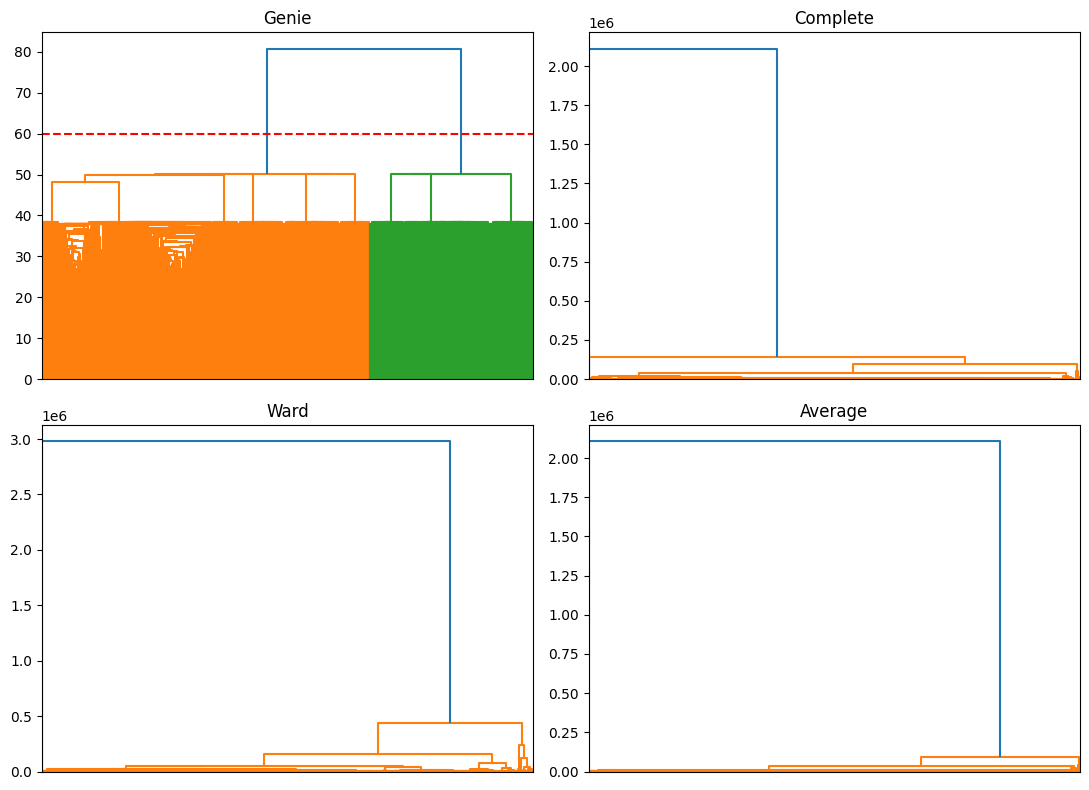

In [ ]:
g = genieclust.Genie()
g.fit(df1)
rows =[]

linkage_matrix = np.column_stack([g.children_, g.distances_, g.counts_])
fig, axs = plt.subplots(2, 2, figsize=(11,8))
hierarchy.dendrogram(linkage_matrix,ax=axs[0,0],show_leaf_counts=False,no_labels=True)
axs[0,0].axhline(y=60,color='red',linestyle='--')
axs[0,0].set_title("Genie")
clusters = fcluster(linkage_matrix, 2, criterion='maxclust')
rows.append({
            "method": 'genie',
            "SSE": cluster_master.sse_labs(clusters, X),
            "Calinski-Harabasz": cluster_master.calinski_harabasz_labs(clusters, X),
            "Silhouette": cluster_master.average_silhouette_labs(clusters, X)})


Z = hierarchy.linkage(df1, 'complete')
hierarchy.dendrogram(Z,ax=axs[0,1],show_leaf_counts=False,no_labels=True)
axs[0,1].set_title("Complete")
clusters = fcluster(Z, 2, criterion='maxclust')
rows.append({
            "method": 'complete',
            "SSE": cluster_master.sse_labs(clusters, X),
            "Calinski-Harabasz": cluster_master.calinski_harabasz_labs(clusters, X),
            "Silhouette": cluster_master.average_silhouette_labs(clusters, X)})


Z = hierarchy.linkage(df1, 'ward')
hierarchy.dendrogram(Z,ax=axs[1,0],show_leaf_counts=False,no_labels=True)
axs[1,0].set_title("Ward")
clusters = fcluster(Z, 2, criterion='maxclust')
rows.append({
            "method": 'Ward',
            "SSE": cluster_master.sse_labs(clusters, X),
            "Calinski-Harabasz": cluster_master.calinski_harabasz_labs(clusters, X),
            "Silhouette": cluster_master.average_silhouette_labs(clusters, X)})

Z = hierarchy.linkage(df1, 'average')
hierarchy.dendrogram(Z,ax=axs[1,1],show_leaf_counts=False,no_labels=True)
axs[1,1].set_title("Average")
clusters = fcluster(Z, 2, criterion='maxclust')
rows.append({
            "method": 'average',
            "SSE": cluster_master.sse_labs(clusters, X),
            "Calinski-Harabasz": cluster_master.calinski_harabasz_labs(clusters, X),
            "Silhouette": cluster_master.average_silhouette_labs(clusters, X)})


plt.tight_layout()
plt.show()

In [ ]:
results= pd.DataFrame(rows)
results

,method,SSE,Calinski-Harabasz,Silhouette
0,genie,4.539471e+12,24.356215,0.443893
1,complete,1.566403e+11,56610.354453,0.997059
2,Ward,1.566403e+11,56610.354453,0.997059
3,average,1.566403e+11,56610.354453,0.997059


Genie osiągnął dobry wynik sylwetki na poziomie 0.44. Pozostałe metody osiągnęły wynik bliski 1, ale nie jest on istotny, bo wynika z patologicznego podziału, czyli wrzucenie wszystkiego do jednego klastra poza jedną obserwacją.

Dużo outlierów, które uniemożliwiają podział.

In [ ]:
# Wyrzucamy outliery

from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20)
labels = lof.fit_predict(df1.select_dtypes(include='number'))

df_clean = df1[labels == 1]

In [ ]:
X=df_clean.to_numpy()

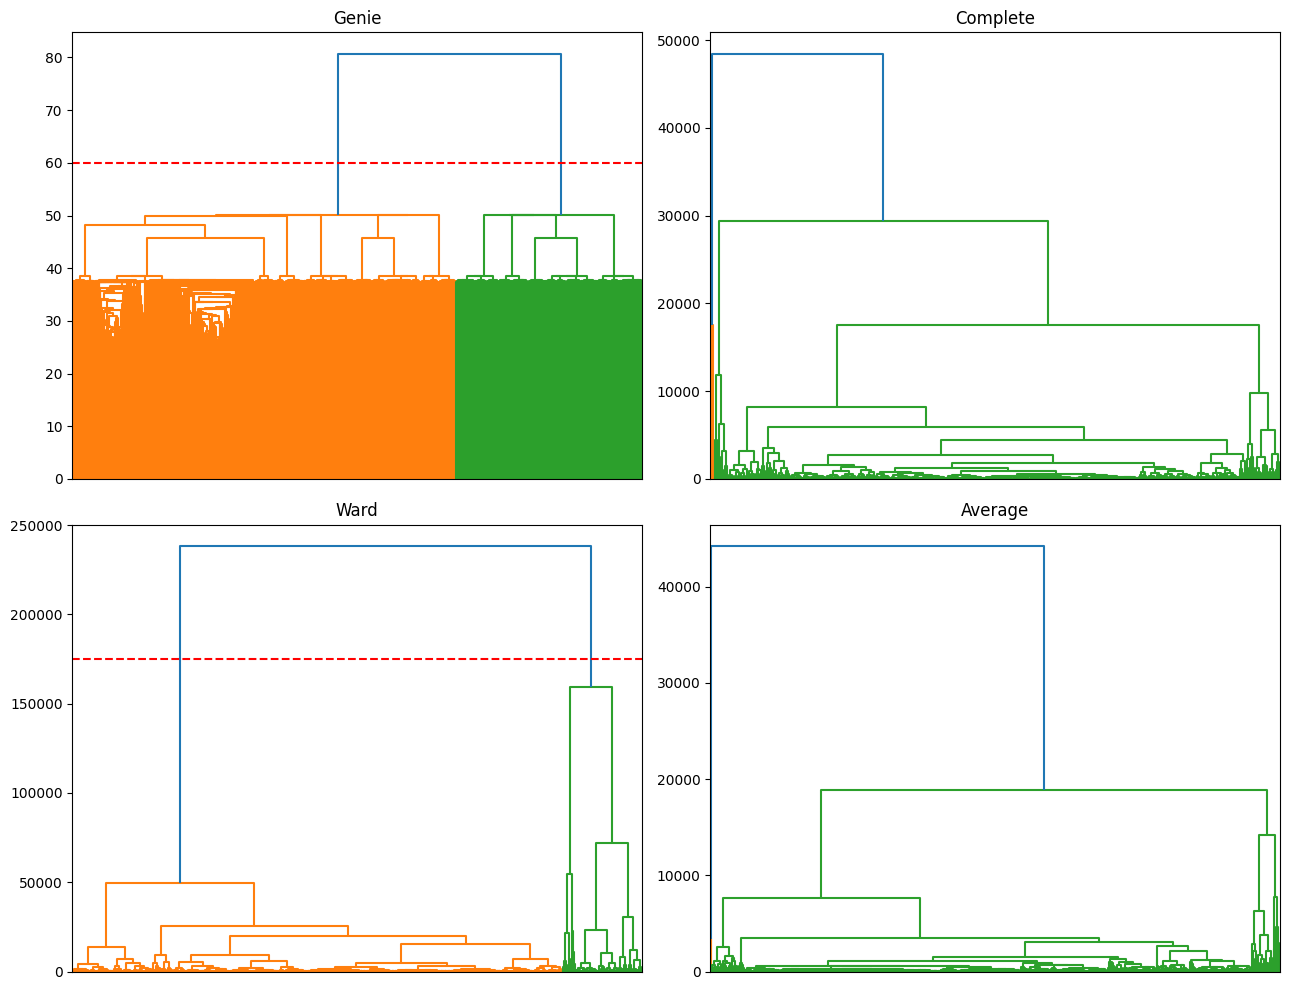

In [ ]:
rows=[]
g = genieclust.Genie()
g.fit(df_clean)
linkage_matrix = np.column_stack([g.children_, g.distances_, g.counts_])
fig, axs = plt.subplots(2, 2, figsize=(13,10))
hierarchy.dendrogram(linkage_matrix,ax=axs[0,0],show_leaf_counts=False,no_labels=True)
axs[0,0].axhline(y=60,color='red',linestyle='--')
axs[0,0].set_title("Genie")
clusters = fcluster(linkage_matrix, 2, criterion='maxclust')
rows.append({
            "method": 'genie',
            "SSE": cluster_master.sse_labs(clusters, X),
            "Calinski-Harabasz": cluster_master.calinski_harabasz_labs(clusters, X),
            "Silhouette": cluster_master.average_silhouette_labs(clusters, X)})


Z = hierarchy.linkage(df_clean, 'complete')
a=fcluster(Z, 2, criterion='maxclust')
axs[0,1].set_title("Complete")
clusters = fcluster(Z, 2, criterion='maxclust')
rows.append({
            "method": 'complete',
            "SSE": cluster_master.sse_labs(clusters, X),
            "Calinski-Harabasz": cluster_master.calinski_harabasz_labs(clusters, X),
            "Silhouette": cluster_master.average_silhouette_labs(clusters, X)})



hierarchy.dendrogram(Z,ax=axs[0,1],show_leaf_counts=False,no_labels=True)
Z = hierarchy.linkage(df_clean, 'ward')
rows.append({
            "method": 'Ward',
            "SSE": cluster_master.sse_labs(clusters, X),
            "Calinski-Harabasz": cluster_master.calinski_harabasz_labs(clusters, X),
            "Silhouette": cluster_master.average_silhouette_labs(clusters, X)})

hierarchy.dendrogram(Z,ax=axs[1,0],show_leaf_counts=False,no_labels=True)
axs[1,0].set_title("Ward")
axs[1,0].axhline(y=175000,color='red',linestyle='--')
Z = hierarchy.linkage(df_clean, 'average')
c=fcluster(Z, 2, criterion='maxclust')

hierarchy.dendrogram(Z,ax=axs[1,1],show_leaf_counts=False,no_labels=True)
axs[1,1].set_title("Average")
clusters = fcluster(Z, 2, criterion='maxclust')
rows.append({
            "method": 'average',
            "SSE": cluster_master.sse_labs(clusters, X),
            "Calinski-Harabasz": cluster_master.calinski_harabasz_labs(clusters, X),
            "Silhouette":cluster_master.average_silhouette_labs(clusters, X)})


plt.tight_layout()
plt.show()

In [ ]:
results= pd.DataFrame(rows)
results

,method,SSE,Calinski-Harabasz,Silhouette
0,genie,3.305559e+10,922.640941,0.519039
1,complete,3.296191e+10,930.685554,0.880852
2,Ward,3.296191e+10,930.685554,0.880852
3,average,4.513554e+10,165.056154,0.899388


Osiągamy lepszą klasteryzację dla meteody Warda. Poprawia nam się też silhouette dla algorytmu Genie. Ponadto widzimy, że optymalne będą dwa klastry. Używamy tylko metod hierachicznych, gdyż inne metody nie sprawdzają się dla tego zbioru, z powodu za dużej liczby outlierów.

Sprawdzimy podział zaproponowany przez algorytm Genie i metodę Warda.

In [ ]:
g = genieclust.Genie(n_clusters=2)
clusters=g.fit_predict(df_clean)
df_clean['cluster'] = clusters
df_grp=df_clean.groupby('cluster').mean()
num_cols = df_clean.drop(columns='cluster').select_dtypes(include='number').columns

df_std = df_clean.copy()
df_std[num_cols] = StandardScaler().fit_transform(df_std[num_cols])

cluster_means_std = df_std.groupby('cluster').mean()

diffs = cluster_means_std.iloc[0]- cluster_means_std.iloc[1]

print(diffs.sort_values(ascending=False))

influencer_status_No                  0.191011
following_count                       0.169852
comments_per_day                      0.133641
sleep_disruption_Mild impact          0.058456
peak_usage_time_Afternoon (12-4pm)    0.043735
                                        ...   
monthly_spend_via_social_usd         -0.069329
daily_usage_hours                    -0.143812
influencer_status_Yes                -0.191011
avg_session_duration_min             -0.191497
followers_count                      -1.225450
Length: 102, dtype: float64


In [ ]:
top_cols = np.abs(diffs).nlargest(10).index

df_grp[top_cols].T

cluster,0,1
followers_count,438.776224,6608.695024
avg_session_duration_min,41.804584,49.299358
influencer_status_No,1.000000,0.808989
influencer_status_Yes,0.000000,0.191011
following_count,477.516706,380.930979
daily_usage_hours,2.871795,3.134189
comments_per_day,4.057498,3.791332
monthly_spend_via_social_usd,21.179946,23.393660
sleep_disruption_Mild impact,0.369852,0.311396
privacy_setting_Private,0.213675,0.258427


In [ ]:
Z = hierarchy.linkage(X, 'ward')
clusters = fcluster(Z, 2, criterion='maxclust')
df_clean['cluster'] = clusters
df_grp=df_clean.groupby('cluster').mean()
num_cols = df_clean.drop(columns='cluster').select_dtypes(include='number').columns

df_std = df_clean.copy()
df_std[num_cols] = StandardScaler().fit_transform(df_std[num_cols])

cluster_means_std = df_std.groupby('cluster').mean()

diffs = cluster_means_std.iloc[0]- cluster_means_std.iloc[1]

print(diffs.sort_values(ascending=False))

influencer_status_No               0.447368
following_count                    0.152460
posts_per_week                     0.076988
notification_frequency_Selected    0.073894
comments_per_day                   0.072810
                                     ...   
dms_sent_per_day                  -0.116630
daily_usage_hours                 -0.172681
avg_session_duration_min          -0.263593
influencer_status_Yes             -0.447368
followers_count                   -2.211794
Length: 102, dtype: float64


In [ ]:
top_cols = np.abs(diffs).nlargest(10).index
df_grp[top_cols].T

cluster,1,2
followers_count,900.392336,12036.379699
influencer_status_Yes,0.000000,0.447368
influencer_status_No,1.000000,0.552632
avg_session_duration_min,42.812470,53.128947
daily_usage_hours,2.913504,3.228571
following_count,458.086375,371.390977
dms_sent_per_day,7.981144,8.304511
posts_per_week,2.967762,2.838346
notification_frequency_Selected,0.397202,0.323308
comments_per_day,3.990876,3.845865


Możemy zauważyć, że obie metody dokonały klasteryzacji wg. podziału ze względu na bycie influencerem. Metoda Warda zdecydowanie lepiej sobie poradziła z tym probelemem tworząc jedną grupę bez inluencerów, a drugą złożoną w 45% z influencerów. Dzięki takiej klasteryzacji możemy zauważyć, że to właśnie bycie influencerem powoduje, że sposób użytkowania social mediów staje się całkowicie inny. Możemy zauważyć, że influencerzy mają większy czas użytkowania dzienny, jak i na jedną sesję, oraz w oczywisty sposób znacznie więcej followerów. Z drugiej strony rzadziej niż przeciętny użytkownik followują inne konta, a także, co bardzo interesujące, wrzucają rzadziej posty oraz komentarze, co może być spowodowane faktem, że bardziej dbają o to jakie treści są przez nich tworzone. Piszą za to więcej prywatnych wiadomości. Widzimy też, że choć zachowania influencerów są specyficzne, to część osób w podobny sposób użytkuje social media, co możemy zaobserwować poprzez fakt, że w drugim klastrze znajduje się aż 55% osób nie będących influencerami. Możemy też zaobserwować, że pomiędzy klastrami nie ma istotnych różnic, jeśli chodzi o zdrowie psychiczne.

In [ ]:
# https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset

In [ ]:
df = pd.read_csv('spotify_tracks.csv')
df.head()

In [ ]:
# https://www.kaggle.com/datasets/soulcelestia/fbref-data
# jeden ze zbiorów już nieco przerobiony...

In [ ]:
df = pd.read_csv('GoalKeepers_transformed.csv')
df.head()
df=df.iloc[:,:14]
names  = ['PSxG-GA',
  'Goals Against',
  'Save Percentage',
  'PSxG/SoT',
  'Save% (Penalty Kicks)',
  'Clean Sheet Percentage',
  'Touches',
  'Launch %',
  'Goal Kicks',
  'Avg. Length of Goal Kicks',
  'Crosses Stopped %',
  'Def. Actions Outside Pen. Area',
  'Avg. Distance of Def. Actions']
attr_cols = [col for col in df.columns if col.startswith('attr_')]
mapping = dict(zip(attr_cols, names))
df = df.rename(columns=mapping)
# df = df.fillna(0) # braki danych, tylko przy rozwazaniach czy bramkarz gra wysoko, wiec moze starczy wypelnic przez 0?
X = df.drop(columns=['Name'])
col_names = X.columns
X= X.to_numpy()
mediany = np.nanmedian(X, axis=0)
rows, cols = np.where(np.isnan(X))
X[rows, cols] = mediany[cols]

In [ ]:
df['Name'][df['Save% (Penalty Kicks)']==0]

3            Alphonse Areola
4          Kepa Arrizabalaga
5              Sergio Asenjo
8             Oliver Baumann
10            Daniel Bentley
               ...          
127        Wojciech Szczęsny
128       Ciprian Tătărușanu
129    Marc-André ter Stegen
132             Mark Travers
135              Iván Villar
Name: Name, Length: 68, dtype: str

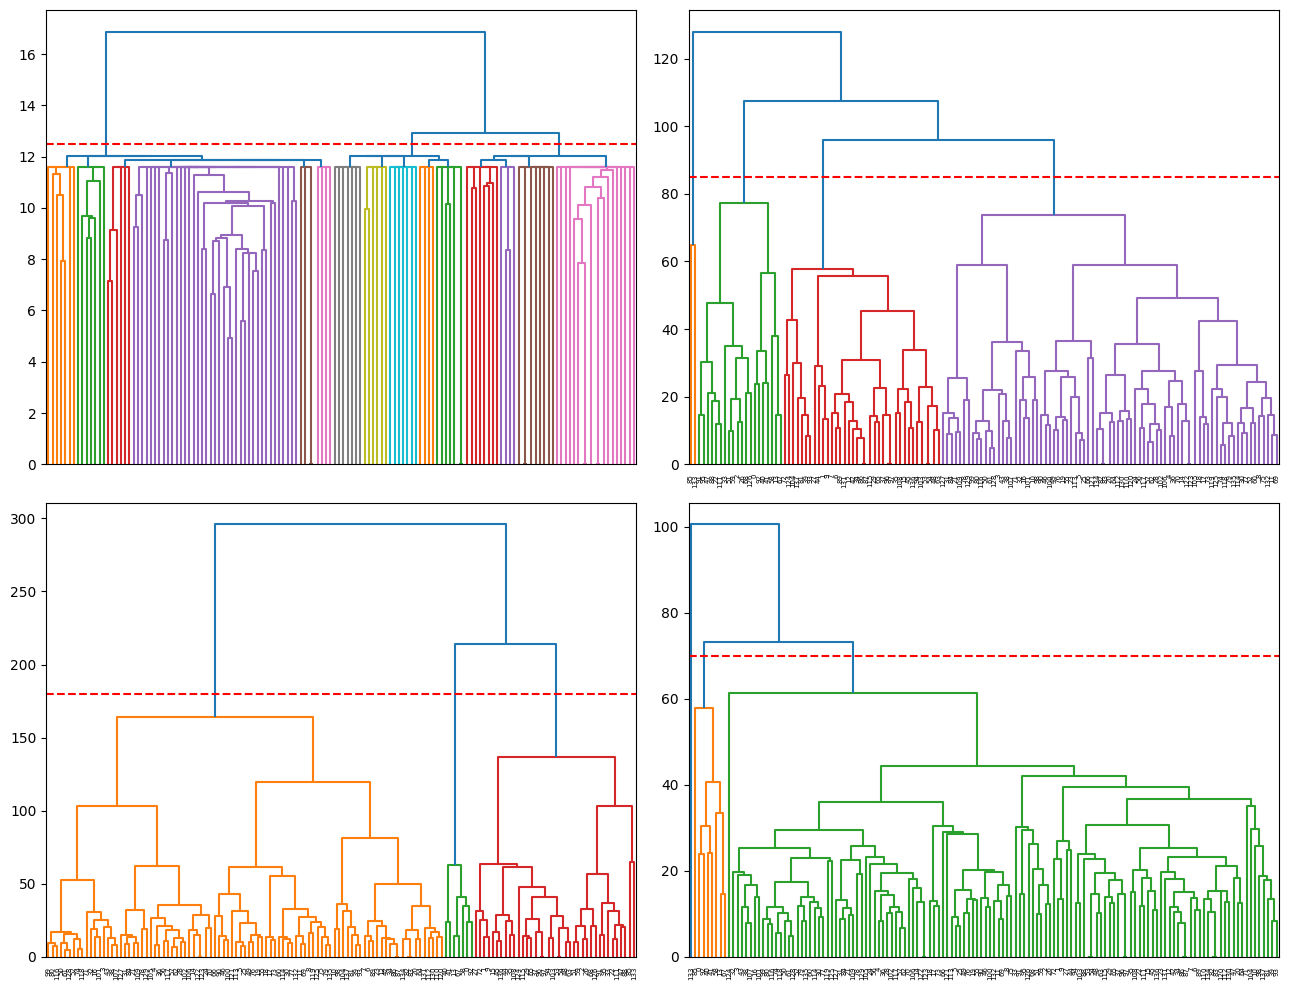

In [ ]:
rows =[]
g = genieclust.Genie()
g.fit(X)
linkage_matrix = np.column_stack([g.children_, g.distances_, g.counts_])
fig, axs = plt.subplots(2, 2, figsize=(13,10))
hierarchy.dendrogram(linkage_matrix,ax=axs[0,0],show_leaf_counts=False,no_labels=True)
Z = hierarchy.linkage(X, 'complete')
hierarchy.dendrogram(Z,ax=axs[0,1])
Z = hierarchy.linkage(X, 'ward')
hierarchy.dendrogram(Z,ax=axs[1,0])
Z = hierarchy.linkage(X, 'average')
hierarchy.dendrogram(Z,ax=axs[1,1])
axs[0,0].axhline(y=12.5,color='red',linestyle='--')
axs[0,1].axhline(y=85,color='red',linestyle='--')
axs[1,0].axhline(y=180,color='red',linestyle='--')
axs[1,1].axhline(y=70,color='red',linestyle='--')

plt.tight_layout()
plt.show()

In [ ]:
g = genieclust.Genie(n_clusters = 3)
labels =g.fit_predict(X)

rows.append({
            "method": 'genie',
            "SSE": cluster_master.sse_labs(labels, X),
            "Calinski-Harabasz": cluster_master.calinski_harabasz_labs(labels, X),
            "Silhouette": cluster_master.average_silhouette_labs(labels, X)})

In [ ]:
Z = hierarchy.linkage(X, 'average')
clusters = fcluster(Z, 3, criterion='maxclust')
#X['cluster'] = clusters
rows.append({
            "method": 'average',
            "SSE": cluster_master.sse_labs(clusters, X),
            "Calinski-Harabasz": cluster_master.calinski_harabasz_labs(clusters, X),
            "Silhouette": cluster_master.average_silhouette_labs(clusters, X)})

In [ ]:
Z = hierarchy.linkage(X, 'complete')
clusters = fcluster(Z, 4, criterion='maxclust')
rows.append({
            "method": 'complete',
            "SSE": cluster_master.sse_labs(clusters, X),
            "Calinski-Harabasz": cluster_master.calinski_harabasz_labs(clusters, X),
            "Silhouette": cluster_master.average_silhouette_labs(clusters, X)})

In [ ]:
Z = hierarchy.linkage(X, 'ward')
clusters = fcluster(Z, 3, criterion='maxclust')
rows.append({
            "method": 'ward',
            "SSE": cluster_master.sse_labs(clusters, X),
            "Calinski-Harabasz": cluster_master.calinski_harabasz_labs(clusters, X),
            "Silhouette": cluster_master.average_silhouette_labs(clusters, X)})

In [ ]:
results= pd.DataFrame(rows)
results

In [ ]:
Z = hierarchy.linkage(X, 'ward')
clusters = fcluster(Z, 3, criterion='maxclust')
X_new = pd.DataFrame(X,columns=col_names)
X_new['cluster'] = clusters
X_new.groupby('cluster').mean()

Patrząc na uzyskane wyniki najlepszym wyborem wydaje się klasteryzacja hierarchiczna oparta na kryterium Warda.

Zwrocmy uwage, ze otrzymujemy podzial na 3 grupy:  

*   Pierwszą grupę charakteryzują trudności z utrzymaniem czystego konta - być może spowodowane jest to słabszą obroną całej drużyny. Patrząc na liczbę kontatktów z piłką na mecz można dojść do wniosku, że jest prawie jak inny gracz w polu, jednak mimo to najwięcej spędza w polu karnym i jest najmniej wysunięty - co wskazuje na defensywny styl gry drużyny, a przy tym bramkarza. Defensywny styl gry potwierdzaja równiez dalekie wykonania od stalych fragmentow gry - od bramki, najprawdopodobniej druzyna ma klopoty ze zbudowaniem akcji ktora mialaby sforsofac defensywe przeciwnika i dlatego decyduje sie na 'atak' od bramki.
*  Ta grupa chrakteryzuje sie najlepszym kontem - najmniej goli na mecz oraz najczesciej czyste konto. Jednak jesli chodzi o interwencje to wskaznik sugeruje w tej grupie nagorsza jakosc, jednak rowniez wskaznik sugeruje ze bramkarze w tej grupie mierza sie z najtrudniejszym strzalami - prawdopodobnie to wynika rowniez ze stylu gry druzyny ma ona prawdopodobnie dobrych obroncow przez co ogolnie malo strzalow udaje sie oddac, jednak jesli juz sa oddane to zostaja juz te najtrudnijesze. Najmniej podan przechodzi przez tego bramkarza jednak wiadac ze potrafi dobrze wspolpracowac z defensywa poniewaz z reguly decyduje sie na bliskie podania.
*   Grupa trzecia charakteryzuje sie spektakularnym interwencjami i najwieksza skutecznoscia jesli chodzi o interwencje zarowno w trakcie gry jak i w trakcie karnych, jednak decyduje sie na gre daleka oraz jest bardziej wysuniety, bardziej ofensywny, byc moze to wynika rowniez z tego ze cala druzyna jest zdecydoanie bardziej ofensywna. Mozna zauwazyc tez ze ten typ bramkarza tez jest czujny gdyz przecina czesto akcje ofensywne druzyny przeciwnej (zabiera pilke w trakcie podania, lub ja wykopuje).
*   Dzieki takie wyodrebnieniu skupien mozna zaobserwoac ze bramkarze decydujacy na gre daleko/ ofensywnie maja najczeciej traca wiecej bramek na mecz, byc moze wykopywanie daleko wiaze sie z szybszym przejeciem pilki przez przeciwnika, a wiec zwiekasza posiadanie pilki przeciwnikowi, a w konskwecnji zwieksza liczbe akcji ofensywnych przeciwnika co skutkuje starconymi bramkami.


